# Notebook 01c · Spatially Stratified Train/Test Split + Spatial CV
## IMD Prediction — Full Spatial Independence Design
### RF / SVR / MLP · Spatial HP Tuning · GEE Raster · Spatial Holdout Evaluation

**Design:**
```
All 3500 points
│
├── Spatial 1km block split (random block assignment)
│   Buffer 250m between train and test
│   -> TRAIN (~70%)          TEST (~30%, locked away)
│
└── On TRAIN only:
     Spatial block CV (500m/1km/2km) for HP tuning
     -> best block size per model
     -> retrain on full TRAIN with best HPs
     -> evaluate on TEST once (final accuracy)
```

---
## Cell 1 · Imports & configuration

In [ ]:
# When needed authenticate and initialise GEE
ee.Authenticate()
ee.Initialize(project='ee-xiaoo')

NameError: name 'ee' is not defined

In [48]:
import os, pyproj
_proj = pyproj.datadir.get_data_dir()
os.environ['PROJ_LIB']  = _proj
os.environ['PROJ_DATA'] = _proj

In [2]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde
import matplotlib.ticker as mticker
import warnings, os, time, json
import joblib
import rasterio
import rioxarray as rxr

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
# ee.Authenticate()  # run once
ee.Initialize(project='ee-xiaoo')

# ── Configuration ──────────────────────────────────────────────────────────────
GEE_PROJECT    = 'ee-xiaoo'
AEF_YEAR       = 2018
RANDOM_STATE   = 42
N_JOBS         = 1
N_FOLDS        = 5        # CV folds within training set
INNER_CV       = 5        # inner folds for HP tuning (can be changed, for example 3 or 5)
BUFFER_M       = 250      # buffer between train/test and between CV folds
SPLIT_BLOCK_M  = 1000     # block size for train/test split
BLOCK_SIZES    = [500, 1000, 2000]   # block sizes tested for HP tuning CV
TEST_FRAC      = 0.30     # target test fraction
N_ITER_RF      = 40
N_ITER_SVR     = 25
N_ITER_MLP     = 20
N_CLASSES      = 7

# ── Paths ──────────────────────────────────────────────────────────────────────
ALL_POINTS_PATH = './outputs_sampling/sample_points_all.gpkg'
OUTPUT_DIR      = './outputs_v2'
RF_RASTER_PATH  = f'{OUTPUT_DIR}/IMD_predicted_RF_spatialCV2_Milan.tif'
SVR_RASTER_PATH = f'{OUTPUT_DIR}/IMD_predicted_SVR_spatialCV2_Milan.tif'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_COLORS = ['#2166ac','#74add1','#abd9e9','#fee090','#f46d43','#d73027','#a50026']
CLASS_LABELS = ['C0 (0%)','C1 (1-20%)','C2 (21-40%)','C3 (41-60%)','C4 (61-80%)','C5 (81-99%)','C6 (100%)']
MODEL_COLORS = {'RF': '#2ecc71', 'SVR': '#3498db', 'MLP': '#9b59b6'}
CV_LABELS    = ['Random'] + [f'{bs}m' for bs in BLOCK_SIZES]

print('Setup OK')
print(f'Split block: {SPLIT_BLOCK_M}m | Buffer: {BUFFER_M}m | Target test: {TEST_FRAC*100:.0f}%')
print(f'CV folds: {N_FOLDS} outer / {INNER_CV} inner | Block sizes: {BLOCK_SIZES} m')


EEException: Caller does not have required permission to use project ee-xiaoo. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=ee-xiaoo and then retry. Propagation of the new permission may take a few minutes.

---
## Cell 2 · Load GEE assets & all 3500 points

In [50]:
# ── GEE ───────────────────────────────────────────────────────────────────────
aoi      = ee.FeatureCollection(f'projects/{GEE_PROJECT}/assets/milano_aoi')
aoi_geom = aoi.geometry()

non_water_mask = (ee.ImageCollection('ESA/WorldCover/v200')
                  .filter(ee.Filter.bounds(aoi_geom))
                  .mosaic().clip(aoi_geom)).neq(80)

start_date = ee.Date.fromYMD(AEF_YEAR, 1, 1)
aef_col    = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
              .filter(ee.Filter.date(start_date, start_date.advance(1, 'year')))
              .filter(ee.Filter.bounds(aoi_geom)))
aef_proj   = aef_col.first().projection()
aef_img    = (aef_col.mosaic()
              .setDefaultProjection(aef_proj)
              .clip(aoi_geom)
              .updateMask(non_water_mask))

band_names = aef_img.bandNames().getInfo()
print(f'AEF bands: {len(band_names)}')

# ── Load all 3500 points ──────────────────────────────────────────────────────
gdf_all = gpd.read_file(ALL_POINTS_PATH).dropna().reset_index(drop=True)
if gdf_all['IMD_class'].dtype != int:
    raw = sorted(gdf_all['IMD_class'].unique())
    gdf_all['IMD_class'] = gdf_all['IMD_class'].map({v: i for i, v in enumerate(raw)})
gdf_all['IMD_class'] = gdf_all['IMD_class'].astype(int)

gdf_utm = gdf_all.to_crs('EPSG:32632')
coords_all = np.column_stack([gdf_utm.geometry.x, gdf_utm.geometry.y])

X_all = gdf_all[band_names].values.astype(np.float32)
y_all = gdf_all['IMD'].values.astype(np.float32)

print(f'Total points: {len(gdf_all)}')
print(f'X shape: {X_all.shape} | y range: {y_all.min():.0f}-{y_all.max():.0f}%')
print(f'Class distribution:')
for c in range(N_CLASSES):
    n = int((gdf_all['IMD_class']==c).sum())
    print(f'  {CLASS_LABELS[c]}: {n}')


AEF bands: 64
Total points: 3500
X shape: (3500, 64) | y range: 0-100%
Class distribution:
  C0 (0%): 500
  C1 (1-20%): 500
  C2 (21-40%): 500
  C3 (41-60%): 500
  C4 (61-80%): 500
  C5 (81-99%): 500
  C6 (100%): 500


---
## Cell 3 · Spatial block functions

In [51]:
# ── Spatial block helper functions ────────────────────────────────────────────
def assign_blocks(coords, block_size):
    bx = (coords[:, 0] // block_size).astype(int)
    by = (coords[:, 1] // block_size).astype(int)
    return np.array([f'{x}_{y}' for x, y in zip(bx, by)])

def blocks_to_folds(block_ids, n_folds, seed):
    rng    = np.random.RandomState(seed)
    unique = rng.permutation(np.unique(block_ids))
    bmap   = {b: i % n_folds for i, b in enumerate(unique)}
    return np.array([bmap[b] for b in block_ids]), bmap

def apply_buffer(train_coords, test_coords, buffer_m):
    if len(train_coords) == 0 or buffer_m == 0:
        return np.ones(len(test_coords), dtype=bool)
    dists, _ = cKDTree(train_coords).query(test_coords, k=1)
    return dists > buffer_m

def make_spatial_splits(point_folds, n_folds):
    all_idx = np.arange(len(point_folds))
    return [(all_idx[point_folds != f], all_idx[point_folds == f])
            for f in range(n_folds)]

print('Spatial block functions defined.')


Spatial block functions defined.


---
## Cell 4 · Spatial train/test split

All 1km blocks randomly shuffled and assigned to test until ~30% reached.
A 250m buffer removes test points too close to training points.

In [52]:
# ── Spatially stratified train/test split ────────────────────────────────────
# Assign all points to 1km blocks, then randomly assign whole blocks to
# train or test until test fraction ~= TEST_FRAC.
# A 250m buffer is applied: test points within BUFFER_M of any training point
# are excluded to ensure spatial independence.

block_ids_all = assign_blocks(coords_all, SPLIT_BLOCK_M)
unique_blocks  = np.unique(block_ids_all)
n_blocks       = len(unique_blocks)

rng = np.random.RandomState(RANDOM_STATE)
shuffled_blocks = rng.permutation(unique_blocks)

# Greedily assign blocks to test until TEST_FRAC reached
test_blocks  = set()
n_total      = len(gdf_all)
n_test_accum = 0
for block in shuffled_blocks:
    if n_test_accum / n_total >= TEST_FRAC:
        break
    test_blocks.add(block)
    n_test_accum += (block_ids_all == block).sum()

test_block_mask  = np.array([b in test_blocks for b in block_ids_all])
train_block_mask = ~test_block_mask

# Apply buffer: remove test points within BUFFER_M of any training point
keep_test = apply_buffer(coords_all[train_block_mask],
                          coords_all[test_block_mask], BUFFER_M)

train_idx = np.where(train_block_mask)[0]
test_idx  = np.where(test_block_mask)[0][keep_test]

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_test  = X_all[test_idx];  y_test  = y_all[test_idx]
coords_train = coords_all[train_idx]
coords_test  = coords_all[test_idx]
gdf_train    = gdf_all.iloc[train_idx].reset_index(drop=True)
gdf_test     = gdf_all.iloc[test_idx].reset_index(drop=True)

print(f'Total blocks: {n_blocks}')
print(f'Test blocks:  {len(test_blocks)} ({100*len(test_blocks)/n_blocks:.1f}% of blocks)')
print(f'Train points: {len(train_idx)} ({100*len(train_idx)/n_total:.1f}%)')
print(f'Test points (before buffer): {test_block_mask.sum()}')
print(f'Test points (after {BUFFER_M}m buffer): {len(test_idx)} ({100*len(test_idx)/n_total:.1f}%)')
print(f'Buffer removed: {(~keep_test).sum()} points ({100*(~keep_test).sum()/test_block_mask.sum():.1f}%)')

# Save splits
gdf_train.to_file(f'{OUTPUT_DIR}/spatial_train_pts.gpkg', driver='GPKG')
gdf_test.to_file(f'{OUTPUT_DIR}/spatial_test_pts.gpkg',  driver='GPKG')
print(f'\nSplits saved to {OUTPUT_DIR}/')


Total blocks: 2089
Test blocks:  611 (29.2% of blocks)
Train points: 2449 (70.0%)
Test points (before buffer): 1051
Test points (after 250m buffer): 1014 (29.0%)
Buffer removed: 37 points (3.5%)

Splits saved to ./outputs_v2/


---
## Cell 5 · Figure 1 — Spatial split visualisation

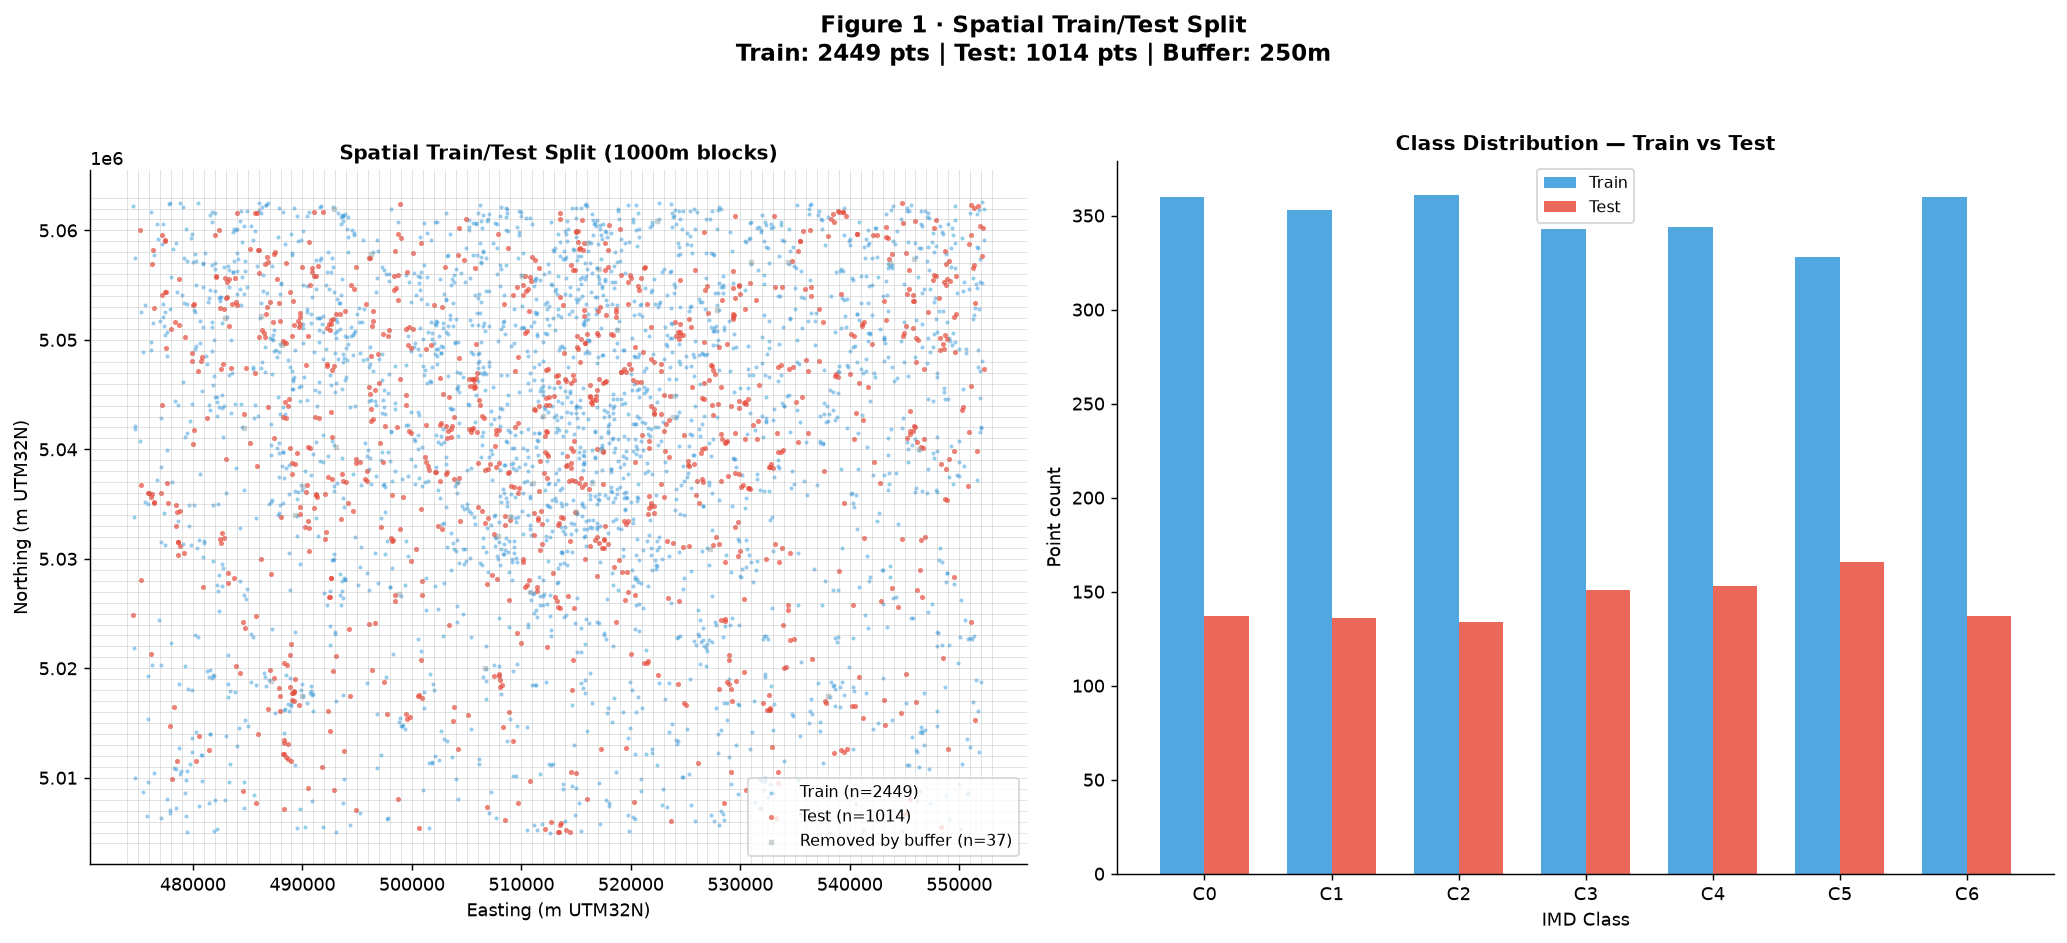

Figure 1 saved.


In [53]:
# Figure 1 -- Spatial train/test split visualisation
fold_colors_tt = {'train': '#3498db', 'test': '#e74c3c', 'removed': '#95a5a6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: block assignment
ax = axes[0]
# colour each block
block_ids_train = assign_blocks(coords_train, SPLIT_BLOCK_M)
block_ids_test  = assign_blocks(coords_test,  SPLIT_BLOCK_M)
removed_coords  = coords_all[test_block_mask][~keep_test]

ax.scatter(coords_train[:, 0], coords_train[:, 1],
           c=fold_colors_tt['train'], s=5, alpha=0.5, linewidths=0, label=f'Train (n={len(train_idx)})')
ax.scatter(coords_test[:, 0], coords_test[:, 1],
           c=fold_colors_tt['test'], s=8, alpha=0.7, linewidths=0, label=f'Test (n={len(test_idx)})')
if len(removed_coords):
    ax.scatter(removed_coords[:, 0], removed_coords[:, 1],
               c=fold_colors_tt['removed'], s=6, alpha=0.5, marker='x',
               label=f'Removed by buffer (n={(~keep_test).sum()})')

# Draw 1km grid
x0, x1 = coords_all[:,0].min(), coords_all[:,0].max()
y0, y1 = coords_all[:,1].min(), coords_all[:,1].max()
for x in np.arange(x0 // SPLIT_BLOCK_M * SPLIT_BLOCK_M, x1 + SPLIT_BLOCK_M, SPLIT_BLOCK_M):
    ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
for y_val in np.arange(y0 // SPLIT_BLOCK_M * SPLIT_BLOCK_M, y1 + SPLIT_BLOCK_M, SPLIT_BLOCK_M):
    ax.axhline(y_val, color='grey', lw=0.3, alpha=0.4)

ax.set_title(f'Spatial Train/Test Split ({SPLIT_BLOCK_M}m blocks)', fontweight='bold')
ax.set_xlabel('Easting (m UTM32N)'); ax.set_ylabel('Northing (m UTM32N)')
ax.set_aspect('equal')
ax.legend(fontsize=9)

# Right: class distribution comparison
ax = axes[1]
x_cls = np.arange(N_CLASSES)
w = 0.35
train_counts = [int((gdf_train['IMD_class']==c).sum()) for c in range(N_CLASSES)]
test_counts  = [int((gdf_test['IMD_class']==c).sum())  for c in range(N_CLASSES)]
ax.bar(x_cls - w/2, train_counts, w, color=fold_colors_tt['train'], alpha=0.85, label='Train')
ax.bar(x_cls + w/2, test_counts,  w, color=fold_colors_tt['test'],  alpha=0.85, label='Test')
ax.set_xticks(x_cls)
ax.set_xticklabels([f'C{c}' for c in range(N_CLASSES)])
ax.set_xlabel('IMD Class'); ax.set_ylabel('Point count')
ax.set_title('Class Distribution — Train vs Test', fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle(f'Figure 1 · Spatial Train/Test Split\n' +
             f'Train: {len(train_idx)} pts | Test: {len(test_idx)} pts | Buffer: {BUFFER_M}m',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_spatial_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


---
## Cell 6 · Hyperparameter tuning (spatial block CV on training set only)

In [54]:
# ── Hyperparameter tuning with 5-fold spatial block CV (training set only) ────
# For each model, RandomizedSearchCV uses spatial block folds of the TRAINING set.
# Three block sizes tested; best block size selected by lowest spatial CV RMSE.

spatial_folds_tune = {}
for bs in BLOCK_SIZES:
    bids = assign_blocks(coords_train, bs)
    pf, _ = blocks_to_folds(bids, N_FOLDS, RANDOM_STATE)
    spatial_folds_tune[bs] = pf

param_spaces = {
    'RF': {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'max_samples':       [None, 0.7, 0.8, 0.9],
    },
    'SVR': {
        'svr__C':       [0.1, 1, 10, 100, 500],
        'svr__epsilon': [0.01, 0.1, 0.5, 1.0],
        'svr__gamma':   ['scale', 'auto', 0.001, 0.01, 0.1],
        'svr__kernel':  ['rbf', 'linear'],
    },
    'MLP': {
        'mlp__hidden_layer_sizes': [(64,), (128,), (64,64), (128,64), (128,128)],
        'mlp__activation':         ['relu', 'tanh'],
        'mlp__alpha':              [0.0001, 0.001, 0.01, 0.1],
        'mlp__learning_rate_init': [0.001, 0.01],
    },
}
base_estimators = {
    'RF':    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    'SVR':   Pipeline([('scaler', StandardScaler()), ('svr',   SVR())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(
               max_iter=500, random_state=RANDOM_STATE))]),
}
n_iters = {'RF': N_ITER_RF, 'SVR': N_ITER_SVR, 'MLP': N_ITER_MLP}

tuned_models         = {}
best_block_per_model = {}
tune_rows            = []

for name in ['RF', 'SVR', 'MLP']:
    print(f'\n{"="*55}')
    print(f'  {name} -- tuning on TRAINING set ({N_FOLDS}-fold spatial CV)')
    print(f'{"="*55}')
    model_best_rmse   = np.inf
    model_best_search = None
    model_best_block  = None

    for bs in BLOCK_SIZES:
        label     = f'{bs}m'
        cv_splits = make_spatial_splits(spatial_folds_tune[bs], N_FOLDS)

        print(f'  {label} ... ', end='', flush=True)
        t0     = time.time()
        search = RandomizedSearchCV(
            estimator           = base_estimators[name],
            param_distributions = param_spaces[name],
            n_iter              = n_iters[name],
            cv                  = cv_splits,
            scoring             = 'neg_root_mean_squared_error',
            n_jobs              = N_JOBS,
            random_state        = RANDOM_STATE,
            refit               = True
        )
        search.fit(X_train, y_train)
        cv_rmse = -search.best_score_
        cv_std  = search.cv_results_['std_test_score'][search.best_index_]
        print(f'{time.time()-t0:.1f}s | CV RMSE={cv_rmse:.3f} ± {cv_std:.3f}')
        print(f'          best params: {search.best_params_}')

        tune_rows.append({'Model': name, 'Block': label,
                           'CV_RMSE': round(cv_rmse, 3),
                           'CV_std':  round(cv_std, 3),
                           'Best_params': str(search.best_params_)})

        if cv_rmse < model_best_rmse:
            model_best_rmse   = cv_rmse
            model_best_search = search
            model_best_block  = label

    tuned_models[name]         = model_best_search.best_estimator_
    best_block_per_model[name] = model_best_block
    print(f'  => Best block for {name}: {model_best_block}  CV RMSE={model_best_rmse:.3f}')

tune_df = pd.DataFrame(tune_rows)
tune_df.to_csv(f'{OUTPUT_DIR}/hyperparameter_tuning.csv', index=False)

print('\n' + '=='*28)
print('  TUNING SUMMARY')
print('=='*28)
for name in tuned_models:
    b    = best_block_per_model[name]
    row  = tune_df[(tune_df['Model']==name) & (tune_df['Block']==b)].iloc[0]
    print(f'  {name:<8}: best block={b}  CV RMSE={row["CV_RMSE"]:.3f} ± {row["CV_std"]:.3f}')
print('=='*28)
print('\nHyperparameter tuning complete.')



  RF -- tuning on TRAINING set (5-fold spatial CV)
  500m ... 618.5s | CV RMSE=13.204 ± 0.273
          best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_samples': 0.9, 'max_features': 0.3, 'max_depth': None}
  1000m ... 624.5s | CV RMSE=13.162 ± 0.502
          best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_samples': 0.9, 'max_features': 0.3, 'max_depth': None}
  2000m ... 620.1s | CV RMSE=13.172 ± 0.476
          best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_samples': 0.9, 'max_features': 0.3, 'max_depth': None}
  => Best block for RF: 1000m  CV RMSE=13.162

  SVR -- tuning on TRAINING set (5-fold spatial CV)
  500m ... 893.0s | CV RMSE=11.711 ± 0.244
          best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.001, 'svr__epsilon': 0.1, 'svr__C': 500}
  1000m ... 545.8s | CV RMSE=11.793 ± 0.582
          best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.001, 'svr_

---
## Cell 7 · Spatial CV evaluation on training set

In [55]:
# ── Spatial CV evaluation on training set (quantify autocorrelation inflation) ─
# This mirrors the design in 01b but operates only on the training set.
# Gives honest CV estimates; test set still untouched.

def run_spatial_cv(model_template, X, y, coords,
                   point_folds, n_folds, buffer_m, is_spatial):
    rows = []
    for fold in range(n_folds):
        tr = point_folds != fold
        te = point_folds == fold
        Xtr, ytr = X[tr], y[tr]
        Xte, yte = X[te], y[te]

        if is_spatial and buffer_m > 0:
            keep = apply_buffer(coords[tr], coords[te], buffer_m)
            Xte, yte = Xte[keep], yte[keep]
            n_removed = (~keep).sum()
        else:
            n_removed = 0

        if len(yte) < 10:
            continue

        m = clone(model_template)
        m.fit(Xtr, ytr)
        yp = np.clip(m.predict(Xte), 0, 100)

        rows.append({
            'fold':      fold,
            'n_train':   int(Xtr.shape[0]),
            'n_test':    int(len(yte)),
            'n_removed': int(n_removed),
            'pct_rem':   round(100 * n_removed / max(te.sum(), 1), 1),
            'RMSE':      float(np.sqrt(mean_squared_error(yte, yp))),
            'MAE':       float(mean_absolute_error(yte, yp)),
            'R2':        float(r2_score(yte, yp)),
            'Bias':      float(np.mean(yte - yp)),
        })
    return pd.DataFrame(rows)

# Pre-compute outer evaluation folds (on training set only)
random_folds_tr = np.zeros(len(X_train), dtype=int)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for fi, (_, tidx) in enumerate(kf.split(X_train)):
    random_folds_tr[tidx] = fi

spatial_folds_eval = {}
for bs in BLOCK_SIZES:
    bids = assign_blocks(coords_train, bs)
    pf, _ = blocks_to_folds(bids, N_FOLDS, RANDOM_STATE)
    spatial_folds_eval[bs] = pf
    n_blocks = len(np.unique(bids))
    counts   = [int((pf==f).sum()) for f in range(N_FOLDS)]
    print(f'{bs}m: {n_blocks} blocks | pts/fold: {counts}')

all_results = {}
total = len(tuned_models) * (1 + len(BLOCK_SIZES))
run_i = 0

for name, model in tuned_models.items():
    run_i += 1
    print(f'\n[{run_i}/{total}] {name} x Random (training set CV)')
    t0 = time.time()
    df = run_spatial_cv(model, X_train, y_train, coords_train,
                        random_folds_tr, N_FOLDS, 0, is_spatial=False)
    print(f'  {time.time()-t0:.1f}s | RMSE: {df["RMSE"].mean():.2f} +/- {df["RMSE"].std():.2f}')
    all_results[(name, 'Random')] = df

    for bs in BLOCK_SIZES:
        run_i += 1
        label = f'{bs}m'
        print(f'[{run_i}/{total}] {name} x {label} (buffer={BUFFER_M}m)')
        t0 = time.time()
        df = run_spatial_cv(model, X_train, y_train, coords_train,
                            spatial_folds_eval[bs], N_FOLDS, BUFFER_M, is_spatial=True)
        print(f'  {time.time()-t0:.1f}s | RMSE: {df["RMSE"].mean():.2f} +/- {df["RMSE"].std():.2f} | ' +
              f'buffer removed: {df["pct_rem"].mean():.1f}%')
        all_results[(name, label)] = df

print(f'\nAll {total} CV runs complete.')


500m: 2079 blocks | pts/fold: [490, 488, 492, 486, 493]
1000m: 1478 blocks | pts/fold: [497, 472, 489, 495, 496]
2000m: 839 blocks | pts/fold: [510, 500, 505, 445, 489]

[1/12] RF x Random (training set CV)
  15.5s | RMSE: 13.33 +/- 0.61
[2/12] RF x 500m (buffer=250m)
  15.2s | RMSE: 13.23 +/- 0.32 | buffer removed: 6.2%
[3/12] RF x 1000m (buffer=250m)
  14.9s | RMSE: 13.17 +/- 0.57 | buffer removed: 3.2%
[4/12] RF x 2000m (buffer=250m)
  15.1s | RMSE: 13.19 +/- 0.56 | buffer removed: 2.0%

[5/12] SVR x Random (training set CV)
  1.4s | RMSE: 11.59 +/- 0.60
[6/12] SVR x 500m (buffer=250m)
  1.3s | RMSE: 11.55 +/- 0.31 | buffer removed: 6.2%
[7/12] SVR x 1000m (buffer=250m)
  1.4s | RMSE: 11.64 +/- 0.67 | buffer removed: 3.2%
[8/12] SVR x 2000m (buffer=250m)
  1.3s | RMSE: 11.65 +/- 0.64 | buffer removed: 2.0%

[9/12] MLP x Random (training set CV)
  11.7s | RMSE: 11.98 +/- 0.77
[10/12] MLP x 500m (buffer=250m)
  11.8s | RMSE: 11.90 +/- 0.22 | buffer removed: 6.2%
[11/12] MLP x 1000m (b

## Test 5 times repeating the folding and then see the mean and stdev

In [56]:
from tqdm import tqdm

N_REPEATS = 5

def run_spatial_cv_repeated(model_template, X, y, coords,
                             block_size, n_folds, buffer_m, is_spatial, n_repeats):
    all_rows = []
    for rep in tqdm(range(n_repeats), desc=f'{"Spatial" if is_spatial else "Random"} {block_size or ""}m', leave=False):
        if is_spatial:
            bids = assign_blocks(coords, block_size)
            pf, _ = blocks_to_folds(bids, n_folds, seed=RANDOM_STATE + rep)
        else:
            pf = np.zeros(len(X), dtype=int)
            kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE + rep)
            for fi, (_, tidx) in enumerate(kf.split(X)):
                pf[tidx] = fi

        df = run_spatial_cv(model_template, X, y, coords, pf, n_folds, buffer_m, is_spatial)
        df['repeat'] = rep
        all_rows.append(df)

    return pd.concat(all_rows, ignore_index=True)

In [57]:
for name, model in tqdm(tuned_models.items(), desc='Models'):
    for bs_label, bs, spatial in (
        [('Random', None, False)] + [(f'{bs}m', bs, True) for bs in BLOCK_SIZES]
    ):
        tqdm.write(f'  {name} x {bs_label}')
        df = run_spatial_cv_repeated(
            model, X_train, y_train, coords_train,
            block_size=bs, n_folds=N_FOLDS,
            buffer_m=BUFFER_M if spatial else 0,
            is_spatial=spatial, n_repeats=N_REPEATS
        )
        all_results[(name, bs_label)] = df

Models:   0%|          | 0/3 [00:00<?, ?it/s]

  RF x Random


Models:   0%|          | 0/3 [01:14<?, ?it/s]

  RF x 500m


Models:   0%|          | 0/3 [02:28<?, ?it/s]

...

Models:  67%|██████▋   | 2/3 [07:15<02:17, 137.21s/it]

  MLP x 1000m


Models:  67%|██████▋   | 2/3 [08:10<02:17, 137.21s/it]

  MLP x 2000m


Models: 100%|██████████| 3/3 [09:06<00:00, 182.05s/it]


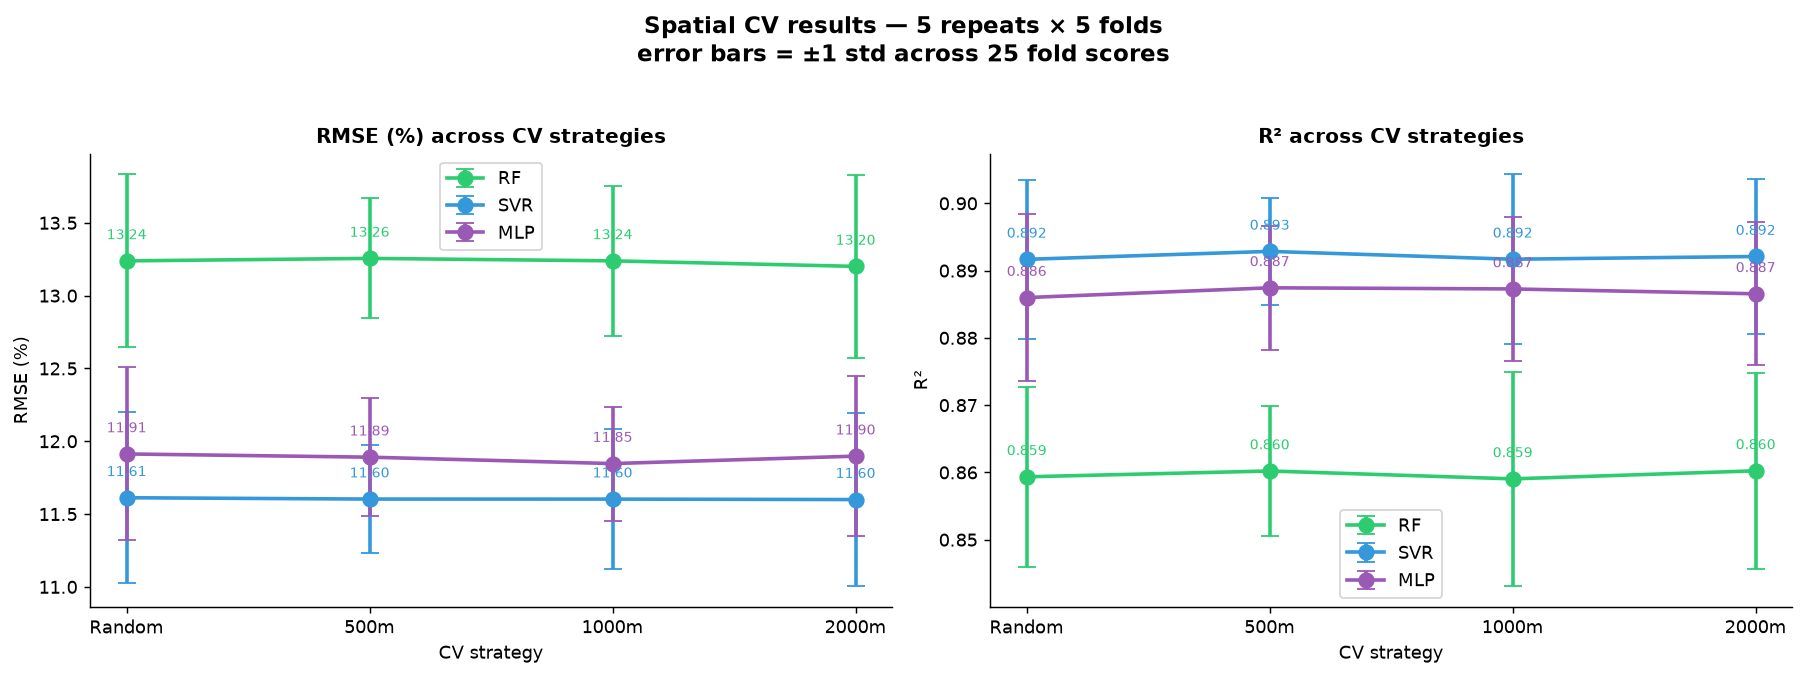

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [('RMSE', axes[0], 'RMSE (%)'), ('R2', axes[1], 'R²')]:
    for name in tuned_models:
        means = [all_results[(name, l)][metric].mean() for l in CV_LABELS]
        stds  = [all_results[(name, l)][metric].std()  for l in CV_LABELS]
        ax.errorbar(range(len(CV_LABELS)), means, yerr=stds,
                    fmt='o-', color=MODEL_COLORS[name], lw=2, ms=8,
                    capsize=5, label=name)
        for i, m in enumerate(means):
            ax.annotate(f'{m:.2f}' if metric=='RMSE' else f'{m:.3f}',
                        (i, m), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=8,
                        color=MODEL_COLORS[name])

    ax.set_xticks(range(len(CV_LABELS)))
    ax.set_xticklabels(CV_LABELS)
    ax.set_xlabel('CV strategy')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} across CV strategies', fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle(f'Spatial CV results — {N_REPEATS} repeats × {N_FOLDS} folds\n'
             f'error bars = ±1 std across {N_REPEATS * N_FOLDS} fold scores',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_repeated_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 · Summary table & best model selection

In [59]:
# Summary table
rows = []
for name in tuned_models:
    for label in CV_LABELS:
        df = all_results[(name, label)]
        rows.append({
            'Model':       name,
            'CV_method':   label,
            'RMSE_mean':   round(df['RMSE'].mean(), 2),
            'RMSE_std':    round(df['RMSE'].std(), 2),
            'MAE_mean':    round(df['MAE'].mean(), 2),
            'MAE_std':     round(df['MAE'].std(), 2),
            'R2_mean':     round(df['R2'].mean(), 3),
            'R2_std':      round(df['R2'].std(), 3),
            'Bias_mean':   round(df['Bias'].mean(), 2),
            'Bias_std':    round(df['Bias'].std(), 2),
            'pct_rem_avg': round(df['pct_rem'].mean(), 1),
        })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(f'{OUTPUT_DIR}/spatial_cv_summary.csv', index=False)

print('=='*35)
print(f'  SPATIAL CV (training set) -- buffer={BUFFER_M}m, {N_FOLDS}-fold')
print('=='*35)
print(summary_df.to_string(index=False))
print('=='*35)

# Best model overall
spatial_labels = [f'{bs}m' for bs in BLOCK_SIZES]
best_rmse = np.inf
BEST_MODEL_NAME  = None
BEST_BLOCK_LABEL = None
for name in tuned_models:
    label = best_block_per_model[name]
    rmse  = all_results[(name, label)]['RMSE'].mean()
    if rmse < best_rmse:
        best_rmse        = rmse
        BEST_MODEL_NAME  = name
        BEST_BLOCK_LABEL = label

BEST_MODEL = tuned_models[BEST_MODEL_NAME]
print(f'\n* Overall best: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}  RMSE={best_rmse:.3f}%')
print(f'  -> GEE raster + holdout evaluation')


  SPATIAL CV (training set) -- buffer=250m, 5-fold
Model CV_method  RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean  R2_std  Bias_mean  Bias_std  pct_rem_avg
   RF    Random      13.24      0.59      9.88     0.45    0.859   0.013      -0.01      0.59          0.0
   RF      500m      13.26      0.41      9.85     0.31    0.860   0.010      -0.07      0.61          6.5
   RF     1000m      13.24      0.51      9.86     0.42    0.859   0.016      -0.04      0.57          3.2
   RF     2000m      13.20      0.63      9.85     0.47    0.860   0.015      -0.01      0.58          1.8
  SVR    Random      11.61      0.59      8.37     0.43    0.892   0.012      -0.29      0.57          0.0
  SVR      500m      11.60      0.37      8.33     0.29    0.893   0.008      -0.40      0.64          6.5
  SVR     1000m      11.60      0.48      8.36     0.40    0.892   0.013      -0.32      0.43          3.2
  SVR     2000m      11.60      0.59      8.36     0.41    0.892   0.011      -0.31      0.66

---
## Cell 9 · Figure 2 — CV fold maps

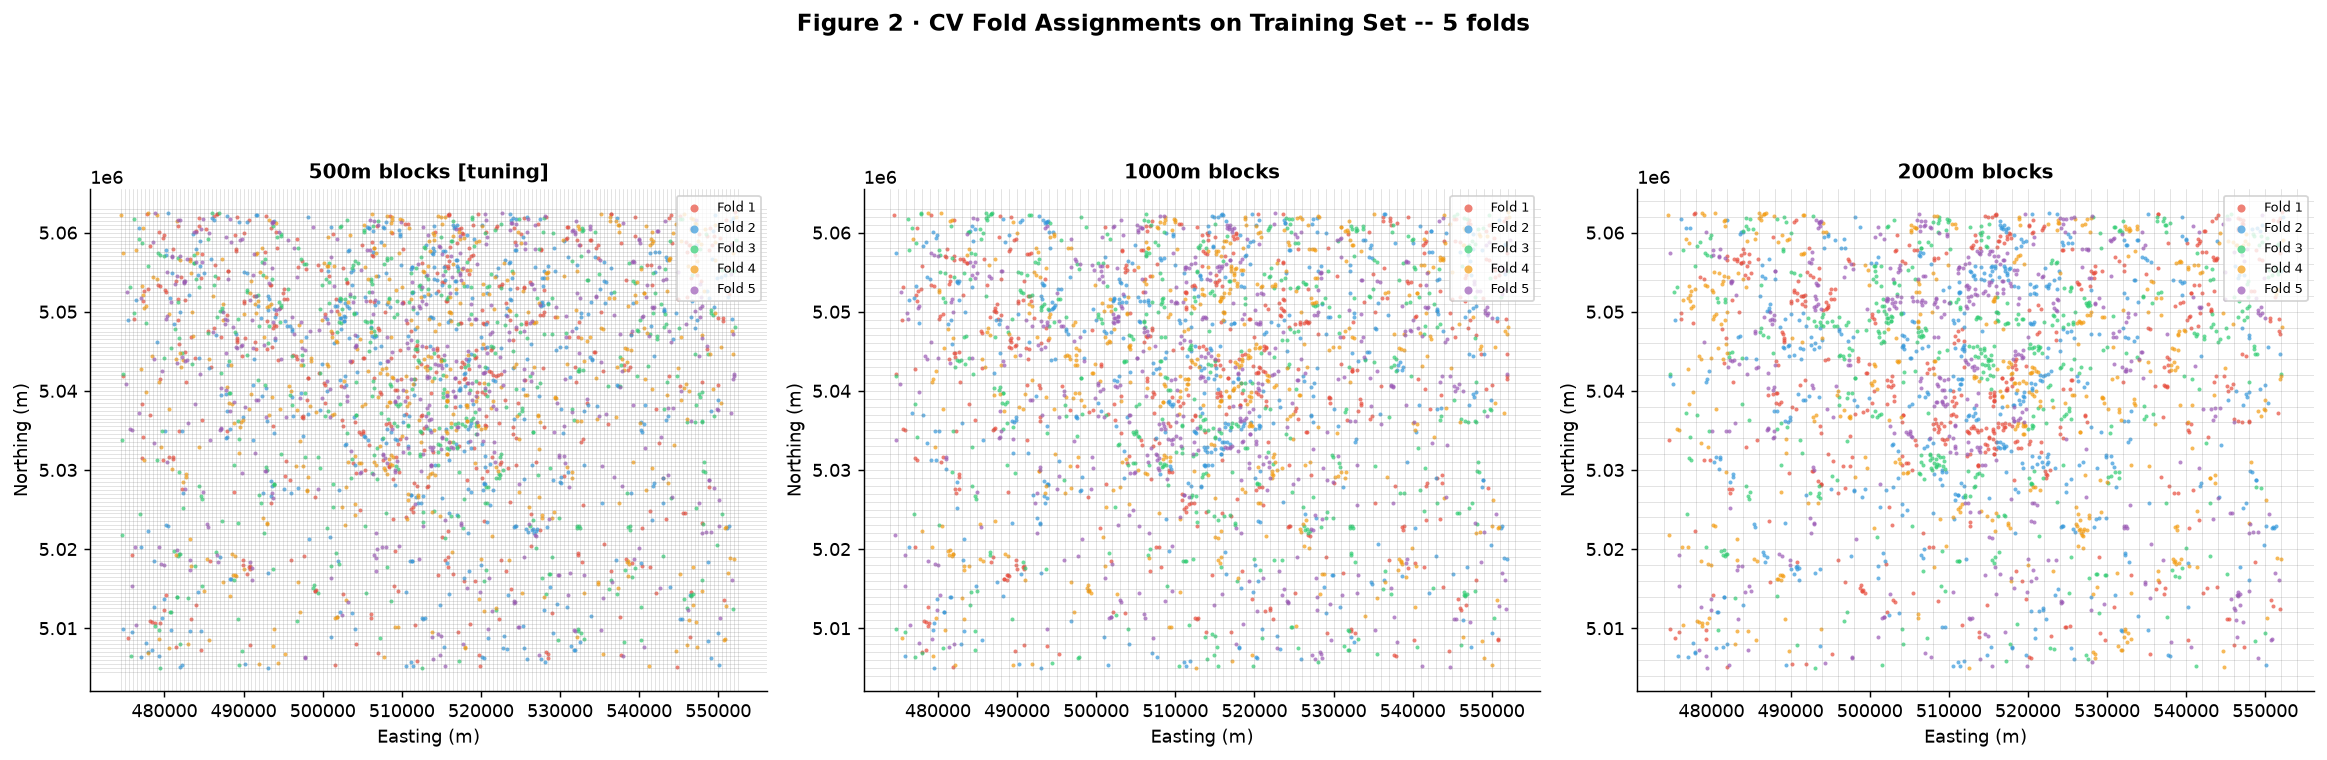

Figure 2 saved.


In [60]:
# Figure 2 -- CV fold maps on training set
fold_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, bs in zip(axes, BLOCK_SIZES):
    pf = spatial_folds_eval[bs]
    for fold in range(N_FOLDS):
        m = pf == fold
        ax.scatter(coords_train[m, 0], coords_train[m, 1],
                   c=fold_colors[fold], s=5, alpha=0.7,
                   label=f'Fold {fold+1}', linewidths=0)
    x0, x1 = coords_train[:,0].min(), coords_train[:,0].max()
    y0, y1 = coords_train[:,1].min(), coords_train[:,1].max()
    for x in np.arange(x0 // bs * bs, x1 + bs, bs):
        ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
    for y_val in np.arange(y0 // bs * bs, y1 + bs, bs):
        ax.axhline(y_val, color='grey', lw=0.3, alpha=0.4)
    marker = ' [tuning]' if f'{bs}m' == best_block_per_model.get(BEST_MODEL_NAME, '') else ''
    ax.set_title(f'{bs}m blocks{marker}', fontweight='bold')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7, markerscale=2)

fig.suptitle(f'Figure 2 · CV Fold Assignments on Training Set -- {N_FOLDS} folds',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


---
## Cell 10 · Figure 3 — RMSE & R² degradation curves

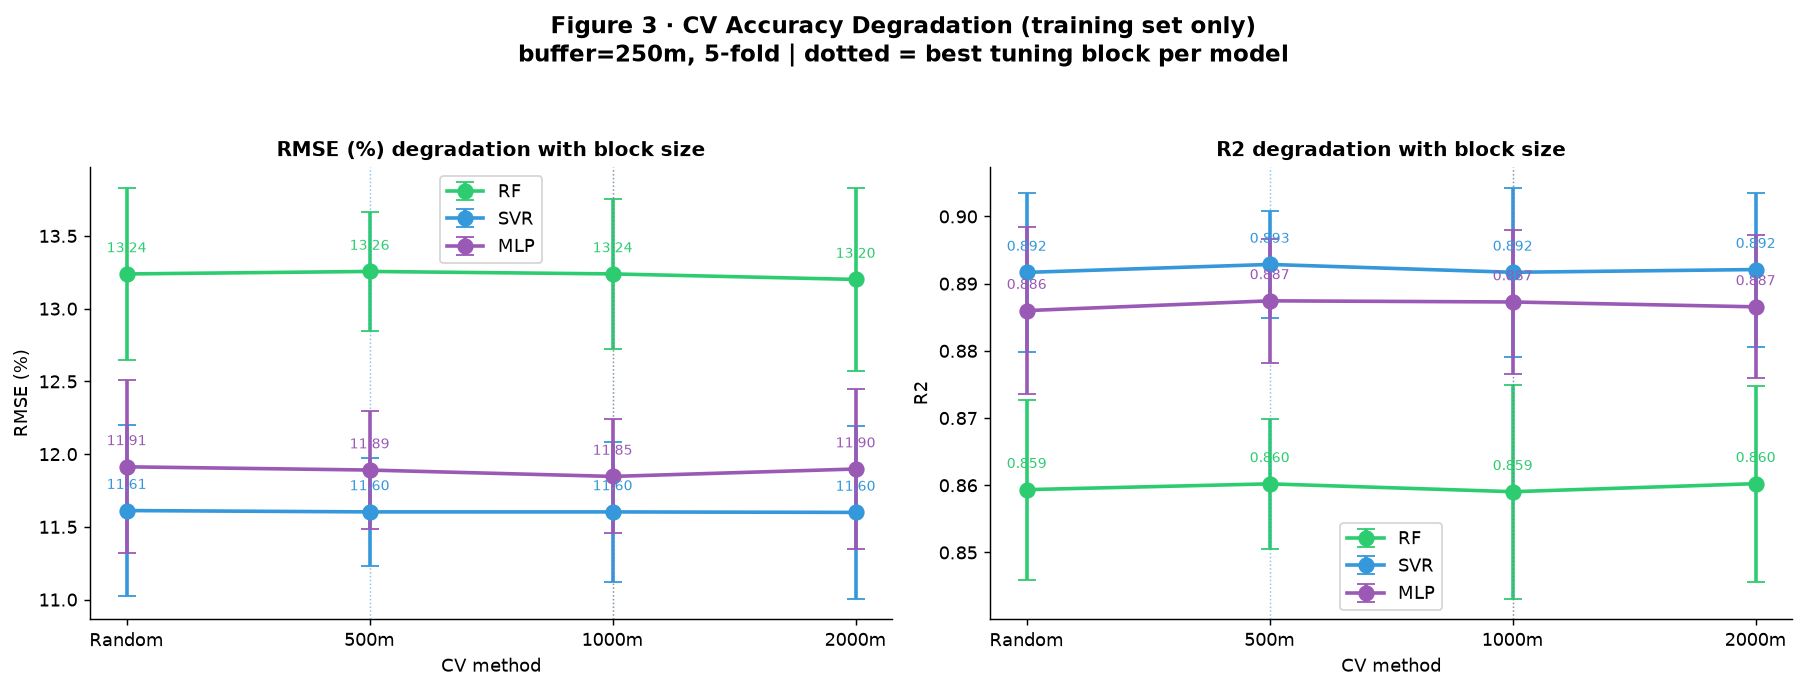

Figure 3 saved.


In [61]:
# Figure 3 -- RMSE & R2 degradation curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, ylabel in [('RMSE', axes[0], 'RMSE (%)'), ('R2', axes[1], 'R2')]:
    for name in tuned_models:
        means = [all_results[(name, l)][metric].mean() for l in CV_LABELS]
        stds  = [all_results[(name, l)][metric].std()  for l in CV_LABELS]
        ax.errorbar(range(len(CV_LABELS)), means, yerr=stds,
                    fmt='o-', color=MODEL_COLORS[name], lw=2, ms=8, capsize=5, label=name)
        for i, m_val in enumerate(means):
            ax.annotate(f'{m_val:.2f}' if metric=='RMSE' else f'{m_val:.3f}',
                        (i, m_val), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=8, color=MODEL_COLORS[name])
        best_b = best_block_per_model[name]
        if best_b in CV_LABELS:
            ax.axvline(CV_LABELS.index(best_b), color=MODEL_COLORS[name],
                       lw=0.8, ls=':', alpha=0.6)
    ax.set_xticks(range(len(CV_LABELS)))
    ax.set_xticklabels(CV_LABELS)
    ax.set_xlabel('CV method'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} degradation with block size', fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle(f'Figure 3 · CV Accuracy Degradation (training set only)\n' +
             f'buffer={BUFFER_M}m, {N_FOLDS}-fold | dotted = best tuning block per model',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig03_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


---
## Cell 11 · Figure 4 — Per-fold RMSE boxplots

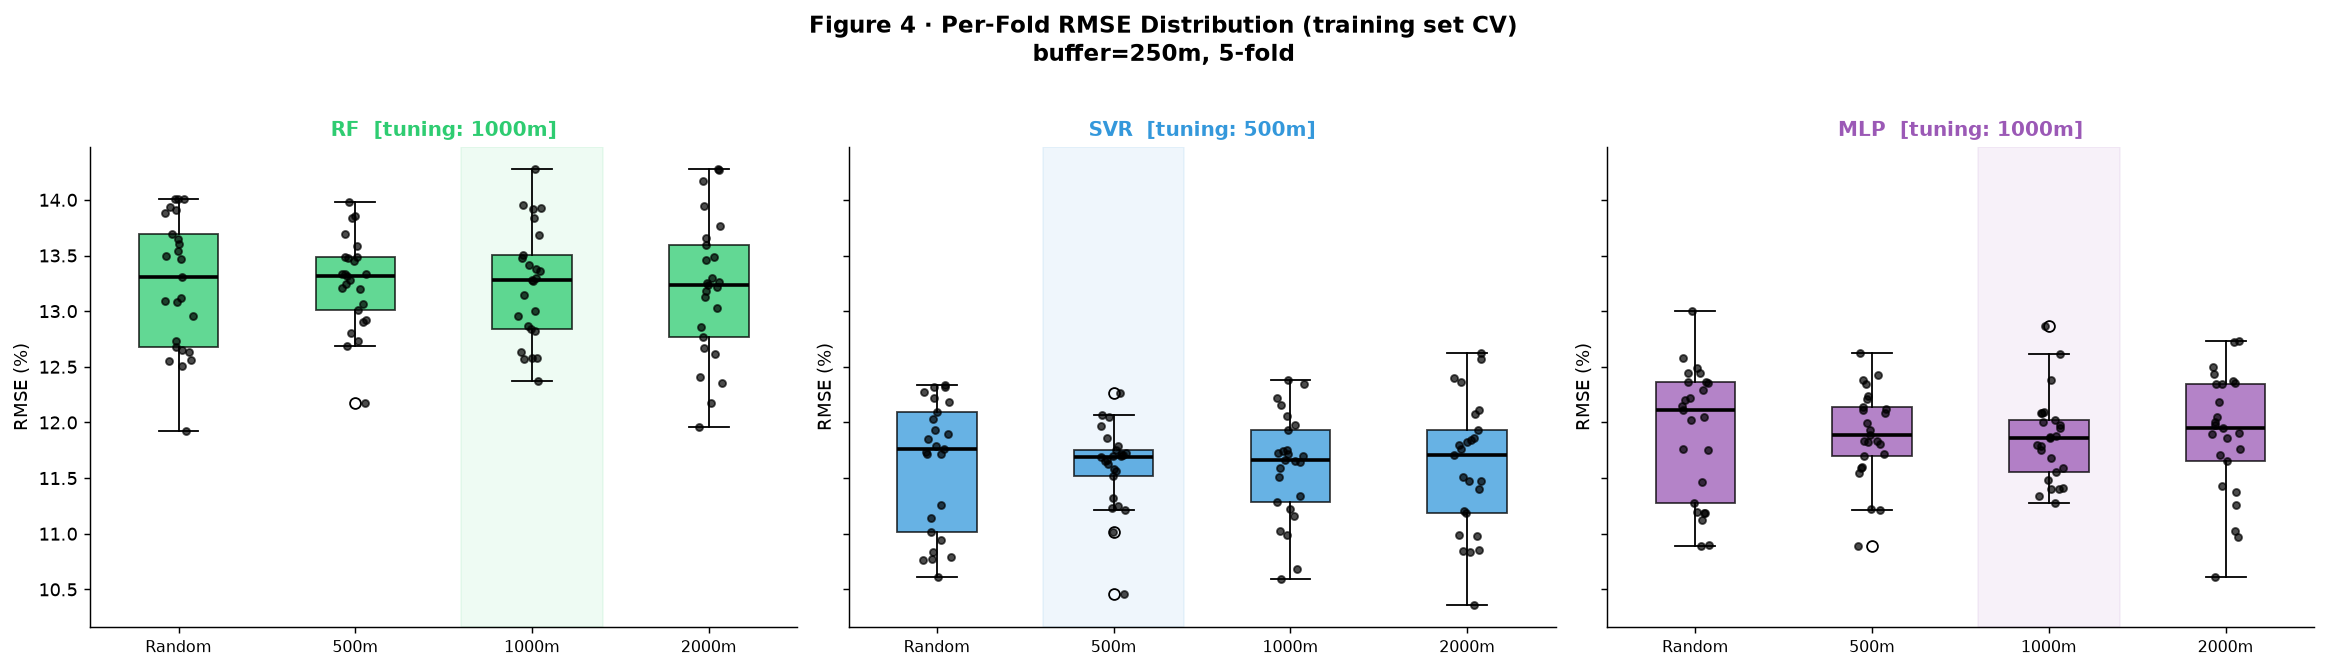

Figure 4 saved.


In [62]:
# Figure 4 -- Per-fold RMSE boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, tuned_models):
    data = [all_results[(name, l)]['RMSE'].values for l in CV_LABELS]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'lw': 1}, capprops={'lw': 1})
    for patch in bp['boxes']:
        patch.set_facecolor(MODEL_COLORS[name]); patch.set_alpha(0.75)
    for i, d in enumerate(data, start=1):
        ax.scatter(np.full(len(d), i) + np.random.uniform(-0.08, 0.08, len(d)),
                   d, c='black', s=15, zorder=5, alpha=0.7)
    best_b = best_block_per_model[name]
    if best_b in CV_LABELS:
        bi = CV_LABELS.index(best_b) + 1
        ax.axvspan(bi-0.4, bi+0.4, alpha=0.08, color=MODEL_COLORS[name])
    ax.set_xticks(range(1, len(CV_LABELS)+1))
    ax.set_xticklabels(CV_LABELS, fontsize=9)
    ax.set_ylabel('RMSE (%)')
    ax.set_title(f'{name}  [tuning: {best_block_per_model[name]}]',
                 fontweight='bold', fontsize=11, color=MODEL_COLORS[name])

fig.suptitle(f'Figure 4 · Per-Fold RMSE Distribution (training set CV)\n' +
             f'buffer={BUFFER_M}m, {N_FOLDS}-fold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig04_rmse_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


---
## Cell 12 · Figure 5 — All metrics grouped bar chart

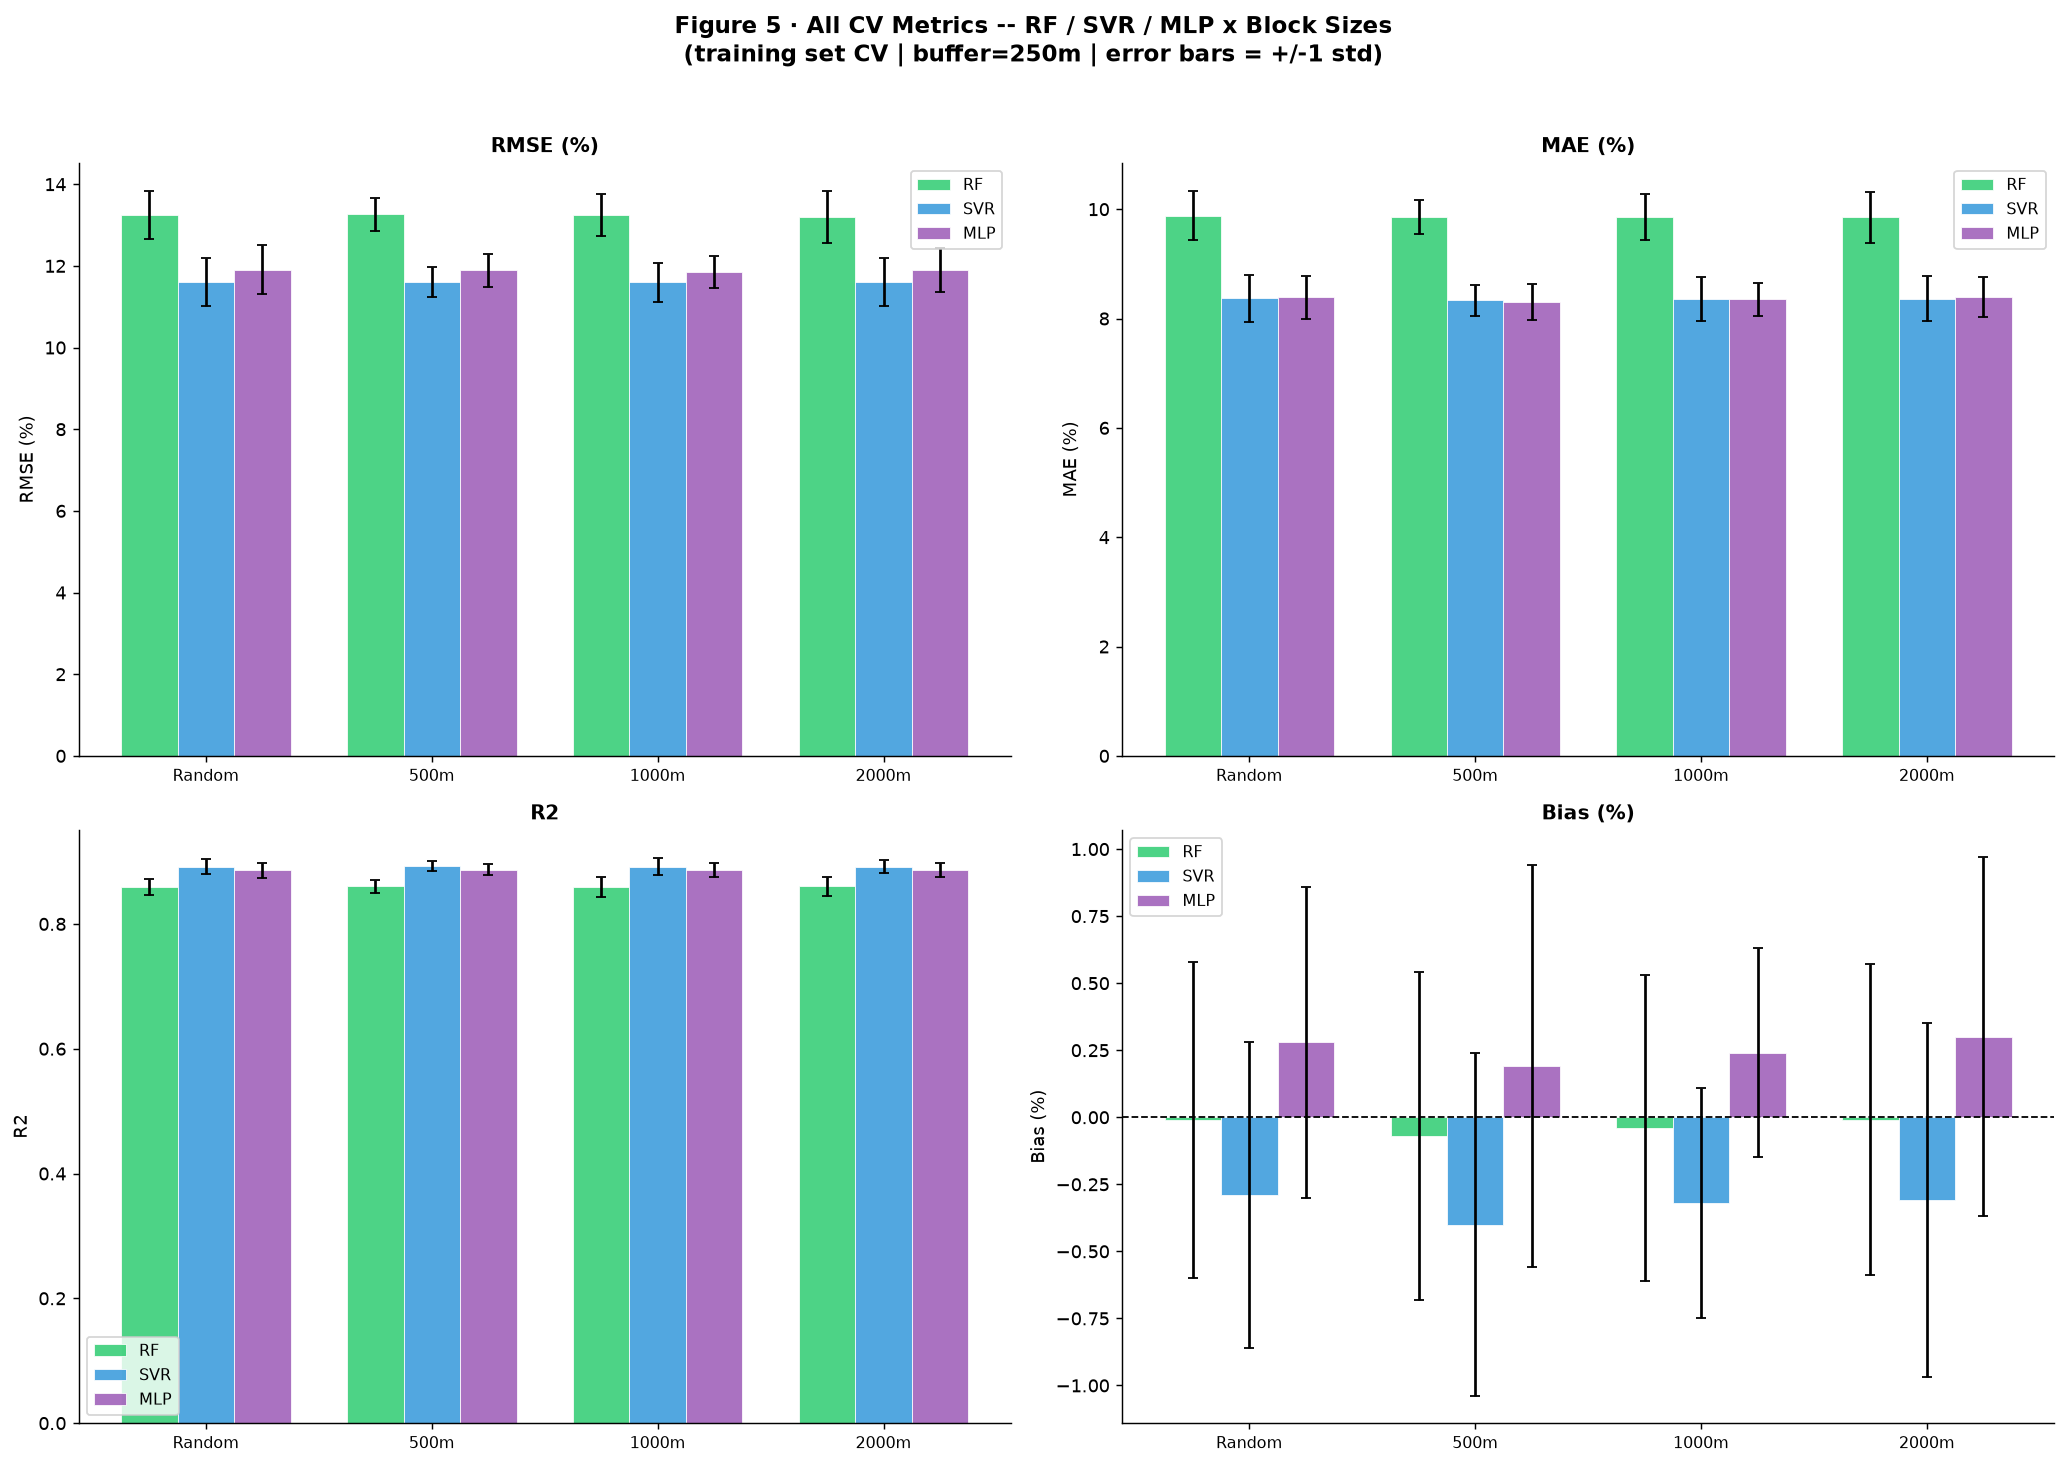

Figure 5 saved.


In [63]:
# Figure 5 -- All metrics grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()
metrics_info = [
    ('RMSE_mean', 'RMSE_std', 'RMSE (%)'),
    ('MAE_mean',  'MAE_std',  'MAE (%)'),
    ('R2_mean',   'R2_std',   'R2'),
    ('Bias_mean', 'Bias_std', 'Bias (%)'),
]
model_names = list(tuned_models.keys())
n_models = len(model_names)
x = np.arange(len(CV_LABELS))
width = 0.25
offsets = {m: (i - n_models//2) * width for i, m in enumerate(model_names)}

for ax, (mean_col, std_col, ylabel) in zip(axes, metrics_info):
    for name in model_names:
        sub  = summary_df[summary_df['Model'] == name].set_index('CV_method')
        vals = [sub.loc[l, mean_col] for l in CV_LABELS]
        errs = [sub.loc[l, std_col]  for l in CV_LABELS]
        ax.bar(x + offsets[name], vals, width,
               color=MODEL_COLORS[name], alpha=0.85,
               label=name, edgecolor='white', lw=0.5,
               yerr=errs, capsize=3)
    if mean_col == 'Bias_mean':
        ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(CV_LABELS, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle(f'Figure 5 · All CV Metrics -- RF / SVR / MLP x Block Sizes\n' +
             f'(training set CV | buffer={BUFFER_M}m | error bars = +/-1 std)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig05_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')


---
## Cell 13 · Figure 6 — Spatial autocorrelation inflation heatmap

   SPATIAL AUTOCORRELATION INFLATION (training set CV)
   Buffer=250m | Folds=5 | Reference: Random CV

  RF  |  Random: RMSE=13.24%  R2=0.859  |  tuning block=1000m
    500m  : RMSE=13.26%  R2=0.860  (+0.02pp, +0.1%)
    1000m : RMSE=13.24%  R2=0.859  (+0.00pp, +0.0%) <- tuning block
    2000m : RMSE=13.20%  R2=0.860  (-0.04pp, -0.3%)

  SVR  |  Random: RMSE=11.61%  R2=0.892  |  tuning block=500m
    500m  : RMSE=11.60%  R2=0.893  (-0.01pp, -0.1%) <- tuning block
    1000m : RMSE=11.60%  R2=0.892  (-0.01pp, -0.1%)
    2000m : RMSE=11.60%  R2=0.892  (-0.01pp, -0.1%)

  MLP  |  Random: RMSE=11.91%  R2=0.886  |  tuning block=1000m
    500m  : RMSE=11.89%  R2=0.887  (-0.02pp, -0.2%)
    1000m : RMSE=11.85%  R2=0.887  (-0.07pp, -0.6%) <- tuning block
    2000m : RMSE=11.90%  R2=0.887  (-0.02pp, -0.1%)


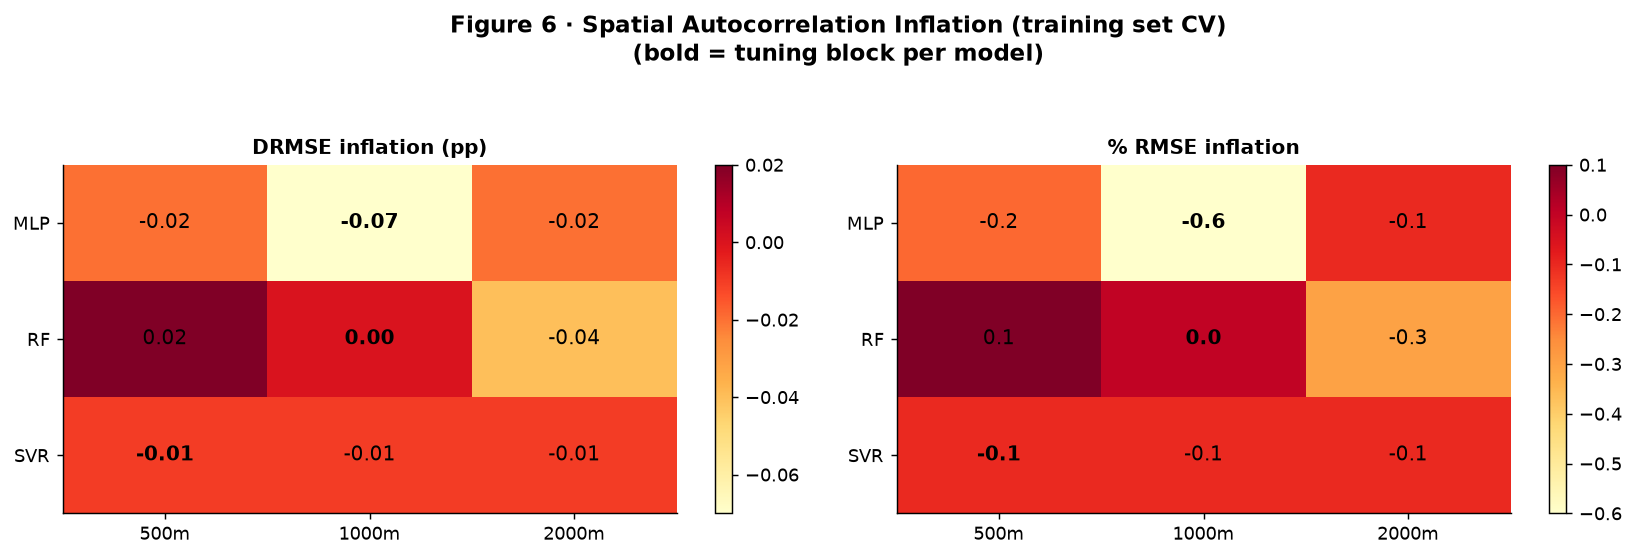

Figure 6 saved.


In [64]:
# Figure 6 -- Spatial autocorrelation inflation heatmap
print('='*65)
print('   SPATIAL AUTOCORRELATION INFLATION (training set CV)')
print(f'   Buffer={BUFFER_M}m | Folds={N_FOLDS} | Reference: Random CV')
print('='*65)

inflation_rows = []
for name in tuned_models:
    rnd_rmse = all_results[(name, 'Random')]['RMSE'].mean()
    rnd_r2   = all_results[(name, 'Random')]['R2'].mean()
    best_b   = best_block_per_model[name]
    print(f'\n  {name}  |  Random: RMSE={rnd_rmse:.2f}%  R2={rnd_r2:.3f}  |  tuning block={best_b}')
    for bs in BLOCK_SIZES:
        label   = f'{bs}m'
        sp_rmse = all_results[(name, label)]['RMSE'].mean()
        sp_r2   = all_results[(name, label)]['R2'].mean()
        diff    = sp_rmse - rnd_rmse
        pct     = 100 * diff / rnd_rmse
        marker  = ' <- tuning block' if label == best_b else ''
        print(f'    {label:<6}: RMSE={sp_rmse:.2f}%  R2={sp_r2:.3f}  ' +
              f'({diff:+.2f}pp, {pct:+.1f}%){marker}')
        inflation_rows.append({
            'Model': name, 'Block': label,
            'Random_RMSE': round(rnd_rmse, 2), 'Spatial_RMSE': round(sp_rmse, 2),
            'RMSE_diff': round(diff, 2), 'Pct_inflation': round(pct, 1),
            'Tuning_block': best_b,
        })

infl_df = pd.DataFrame(inflation_rows)
infl_df.to_csv(f'{OUTPUT_DIR}/inflation_analysis.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, fmt in [
    (axes[0], 'RMSE_diff',     'DRMSE inflation (pp)', '.2f'),
    (axes[1], 'Pct_inflation', '% RMSE inflation',     '.1f'),
]:
    pivot = infl_df.pivot(index='Model', columns='Block', values=col)
    pivot = pivot[[f'{bs}m' for bs in BLOCK_SIZES]]
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(BLOCK_SIZES)))
    ax.set_xticklabels([f'{bs}m' for bs in BLOCK_SIZES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            is_best = (f'{BLOCK_SIZES[j]}m' == best_block_per_model[pivot.index[i]])
            ax.text(j, i, f'{pivot.values[i,j]:{fmt}}',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold' if is_best else 'normal')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)

fig.suptitle('Figure 6 · Spatial Autocorrelation Inflation (training set CV)\n' +
             '(bold = tuning block per model)',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig06_inflation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')


---
## Cell 14 · GEE raster export

Retrain on full training set. Export RF and SVR rasters.
Download GeoTIFFs from Google Drive before Cell 15.

In [65]:
# Retrain best model on full training set and export rasters to GEE
best_model_fitted = clone(BEST_MODEL)
best_model_fitted.fit(X_train, y_train)
joblib.dump(best_model_fitted, f'{OUTPUT_DIR}/best_model_{BEST_MODEL_NAME}.joblib')

# Build GEE FeatureCollection from training points
features = []
for _, row in gdf_train.iterrows():
    props = {b: float(row[b]) for b in band_names}
    props['IMD'] = float(row['IMD'])
    features.append(ee.Feature(None, props))
train_fc = ee.FeatureCollection(features)

def train_gee_regressor(model_type):
    if model_type == 'RF':
        params = tuned_models['RF'].get_params()
        clf = ee.Classifier.smileRandomForest(
            numberOfTrees     = params.get('n_estimators', 200),
            minLeafPopulation = params.get('min_samples_leaf', 1),
            seed              = RANDOM_STATE
        ).setOutputMode('REGRESSION').train(
            features=train_fc, classProperty='IMD', inputProperties=band_names)
    elif model_type == 'SVR':
        svr = tuned_models['SVR'].named_steps['svr']
        clf = ee.Classifier.libsvm(
            svmType     = 'EPSILON_SVR',
            kernelType  = svr.kernel.upper() if isinstance(svr.kernel, str) else 'RBF',
            cost        = float(svr.C),
            gamma       = float(svr.gamma) if isinstance(svr.gamma, (int, float)) else None,
            lossEpsilon = float(svr.epsilon),
        ).setOutputMode('REGRESSION').train(
            features=train_fc, classProperty='IMD', inputProperties=band_names)
    return clf

def make_pred_image(clf):
    return (aef_img.classify(clf).rename('IMD_predicted')
            .clip(aoi_geom).updateMask(non_water_mask))

def export_drive(image, name):
    task = ee.batch.Export.image.toDrive(
        image=image, description=name, folder='GEE_exports',
        fileNamePrefix=name, region=aoi_geom,
        scale=10, crs='EPSG:32632', maxPixels=1e10)
    task.start()
    print(f'  Export started: {name}')

# Always save RF separately (needed for Vietnam transferability)
rf_fitted = clone(tuned_models['RF'])
rf_fitted.fit(X_train, y_train)
joblib.dump(rf_fitted, f'{OUTPUT_DIR}/best_model_RF_spatialcv.joblib')

# Save metadata for Notebook 02
# Guard: holdout_df is created in the Holdout evaluation cell (runs later).
# On the first pass it may not exist yet; fall back to None so this cell
# runs top-to-bottom. Re-run this cell after the Holdout cell to backfill.
_hd = holdout_df if 'holdout_df' in dir() else None
def _hd_val(col):
    if _hd is not None and 'GEE_RF' in _hd['Model'].values:
        return float(_hd[_hd['Model']=='GEE_RF'][col].values[0])
    return None
meta = {
    'best_model_name': BEST_MODEL_NAME,
    'best_block':      BEST_BLOCK_LABEL,
    'band_names':      band_names,
    'best_params':     {k: str(v) for k, v in tuned_models['RF'].get_params().items()},
    'holdout_rmse':    _hd_val('RMSE'),
    'holdout_mae':     _hd_val('MAE'),
    'holdout_r2':      _hd_val('R2'),
    'holdout_bias':    _hd_val('Bias'),
}
with open(f'{OUTPUT_DIR}/model_metadata_spatialcv.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('RF model and metadata saved for Vietnam transferability.')

print('Training GEE RF...')
prediction_rf = make_pred_image(train_gee_regressor('RF'))
export_drive(prediction_rf, 'IMD_predicted_RF_spatialCV2_Milan')

print('Training GEE SVR...')
prediction_svr = make_pred_image(train_gee_regressor('SVR'))
export_drive(prediction_svr, 'IMD_predicted_SVR_spatialCV2_Milan')

print(f'\nBest model: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}')
print('Download GeoTIFFs from Google Drive before Cell 15.')


RF model and metadata saved for Vietnam transferability.
Training GEE RF...
  Export started: IMD_predicted_RF_spatialCV2_Milan
Training GEE SVR...
  Export started: IMD_predicted_SVR_spatialCV2_Milan

Best model: SVR @ 500m
Download GeoTIFFs from Google Drive before Cell 15.


---
## Cell 15 · Holdout test set evaluation

Test set touched for the first time here.
GEE rasters sampled at spatial holdout locations.

In [66]:
# ── Holdout test set evaluation -- touched for the first time ─────────────────
def sample_raster_at_points(raster_path, gdf):
    gdf_r = gdf.to_crs('EPSG:32632')
    coords_pts = [(geom.x, geom.y) for geom in gdf_r.geometry]
    with rasterio.open(raster_path) as src:
        vals = np.array([v[0] for v in src.sample(coords_pts)], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals

# Local sklearn predictions (reference only, printed not plotted)
print('Local sklearn predictions on spatial holdout test set:')
print(f'{"Model":<8} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"Bias":>8}  [tuning block]')
print('-' * 58)
for name, model in tuned_models.items():
    yp = np.clip(model.predict(X_test), 0, 100)
    print(f'  {name:<6}  ' +
          f'RMSE={np.sqrt(mean_squared_error(y_test, yp)):.2f}%  ' +
          f'MAE={mean_absolute_error(y_test, yp):.2f}%  ' +
          f'R2={r2_score(y_test, yp):.3f}  ' +
          f'Bias={np.mean(y_test - yp):+.2f}%  ' +
          f'[{best_block_per_model[name]}]')

# GEE raster evaluation
holdout_results = {}
print(f'\nGEE raster predictions at spatial holdout test locations:')
for label, path in [('GEE_RF', RF_RASTER_PATH), ('GEE_SVR', SVR_RASTER_PATH)]:
    if not os.path.exists(path):
        print(f'  {label}: file not found -- {path}')
        continue
    yp    = np.clip(sample_raster_at_points(path, gdf_test), 0, 100)
    valid = ~np.isnan(yp)
    yt    = y_test[valid]
    yp    = yp[valid]
    metrics = {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
        
        'Bias': float(np.mean(yt - yp)),
        
    }
    holdout_results[label] = {'metrics': metrics, 'y_pred': yp, 'y_true': yt,
                               'cls': gdf_test['IMD_class'].values[valid]}
    print(f'  {label}: RMSE={metrics["RMSE"]:.2f}%  MAE={metrics["MAE"]:.2f}%  ' +
          f'R2={metrics["R2"]:.3f}  Bias={metrics["Bias"]:+.2f}%  (valid: {valid.sum()}/{len(y_test)})')

holdout_df = pd.DataFrame([{'Model': k, **v['metrics']} for k, v in holdout_results.items()]).round(3)
holdout_df.to_csv(f'{OUTPUT_DIR}/holdout_test_metrics.csv', index=False)
print('\nHoldout metrics saved.')


Local sklearn predictions on spatial holdout test set:
Model        RMSE      MAE       R2     Bias  [tuning block]
----------------------------------------------------------
  RF      RMSE=13.97%  MAE=10.31%  R2=0.841  Bias=+0.56%  [1000m]
  SVR     RMSE=11.66%  MAE=8.15%  R2=0.889  Bias=-0.60%  [500m]
  MLP     RMSE=12.23%  MAE=8.42%  R2=0.878  Bias=-0.42%  [1000m]

GEE raster predictions at spatial holdout test locations:
  GEE_RF: RMSE=14.12%  MAE=10.67%  R2=0.837  Bias=+0.62%  (valid: 1014/1014)
  GEE_SVR: RMSE=14.76%  MAE=11.40%  R2=0.822  Bias=+0.27%  (valid: 1014/1014)

Holdout metrics saved.


---
## Cell 16 · Figure 7 — Holdout scatter plots

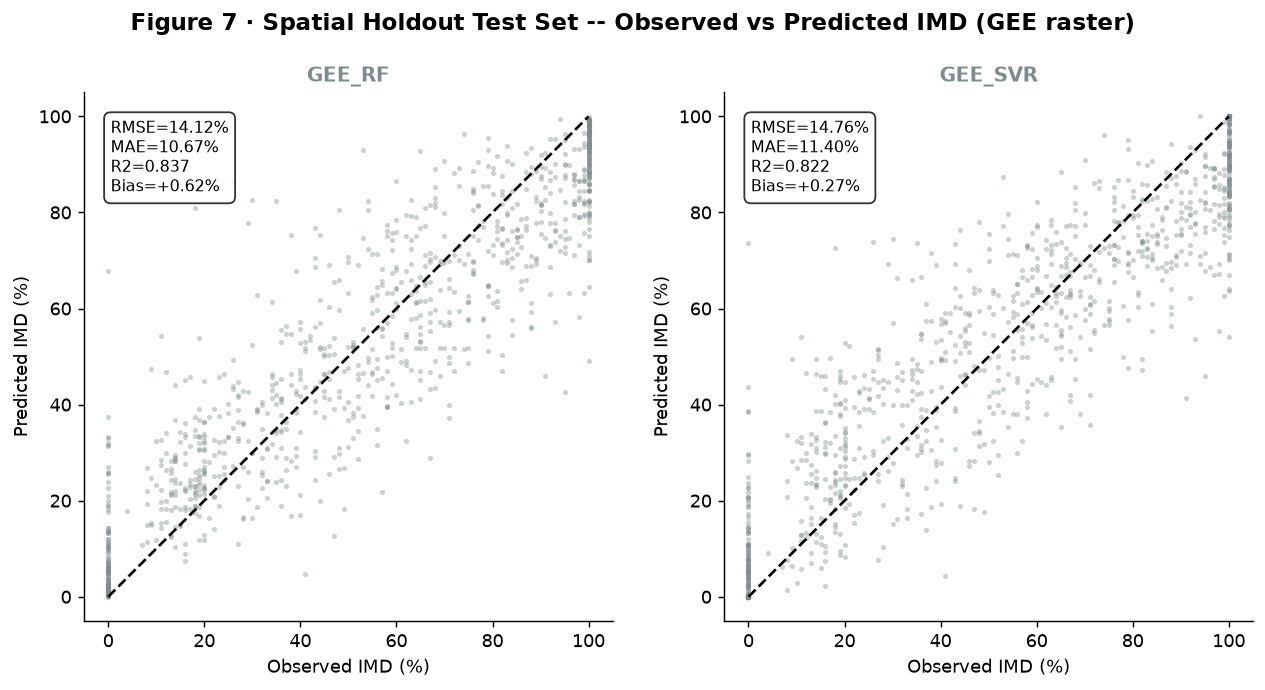

Figure 7 saved.


In [67]:
# Figure 7 -- Holdout scatter plots (GEE rasters)
n_panels = len(holdout_results)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, holdout_results.items()):
    m     = res['metrics']
    yp    = res['y_pred']
    yt    = res['y_true']
    color = MODEL_COLORS.get(name, '#7f8c8d')
    ax.scatter(yt, yp, c=color, s=8, alpha=0.4, linewidths=0)
    ax.plot([0, 100], [0, 100], 'k--', lw=1.5)
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
    ax.set_xlabel('Observed IMD (%)'); ax.set_ylabel('Predicted IMD (%)')
    ax.set_title(name, fontweight='bold', color=color)
    ax.text(0.05, 0.95,
            f'RMSE={m["RMSE"]:.2f}%\nMAE={m["MAE"]:.2f}%\nR2={m["R2"]:.3f}\nBias={m["Bias"]:+.2f}%',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
    ax.set_aspect('equal')

fig.suptitle('Figure 7 · Spatial Holdout Test Set -- Observed vs Predicted IMD (GEE raster)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig07_holdout_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')


---
## Cell 17 · Figure A — Scatter + KDE + error boxplot

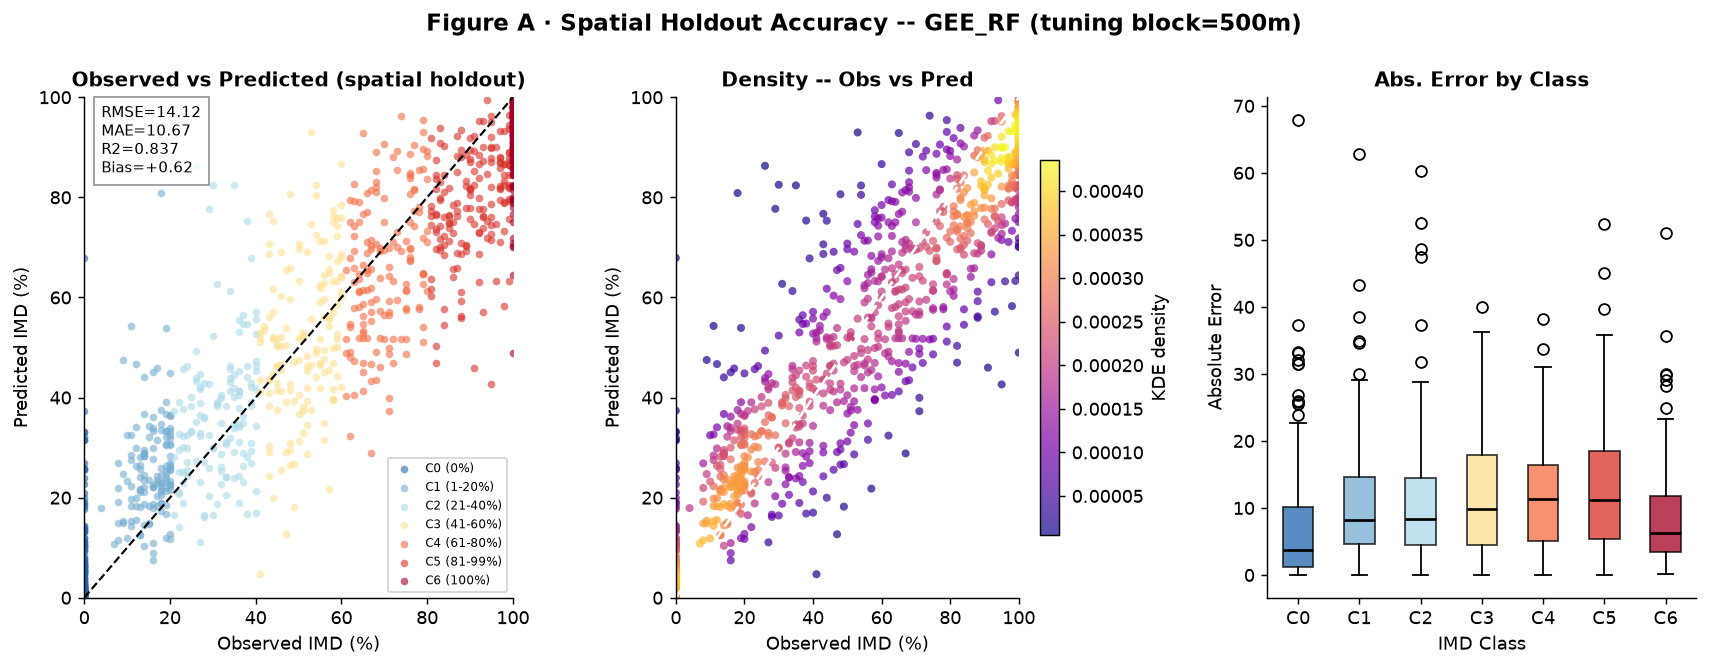

Figure A saved for GEE_RF.


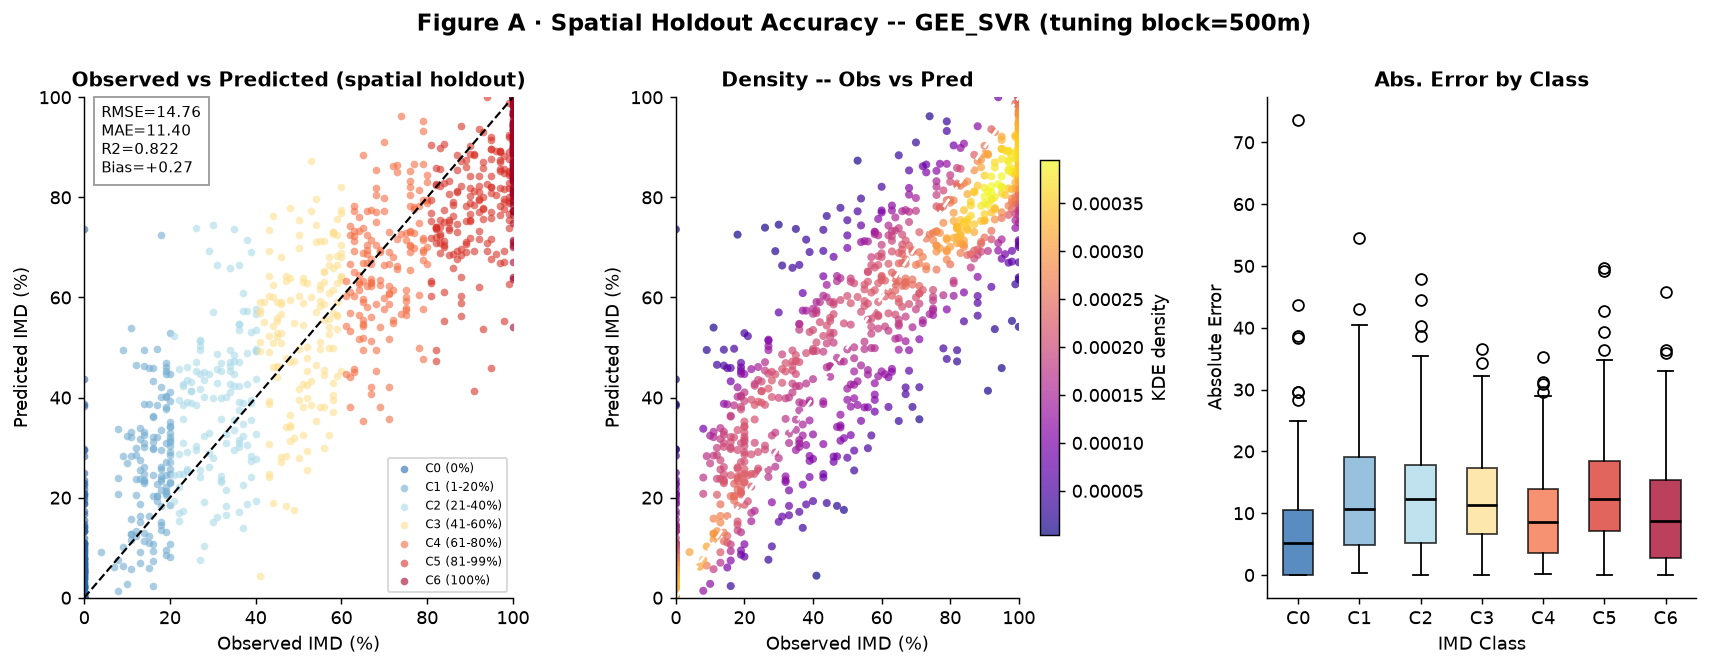

Figure A saved for GEE_SVR.


In [68]:
# Figure A -- Scatter + KDE + error boxplot per GEE model
for name, res in holdout_results.items():
    yt    = res['y_true']
    yp    = res['y_pred']
    ct    = res['cls']
    resid = yt - yp
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    r2    = r2_score(yt, yp)
    bias  = float(np.mean(resid))

    fig = plt.figure(figsize=(16, 5))
    gs  = GridSpec(1, 3, figure=fig, wspace=0.38)

    ax1 = fig.add_subplot(gs[0])
    for c in sorted(np.unique(ct)):
        m = ct == c
        ax1.scatter(yt[m], yp[m], c=CLASS_COLORS[c], s=18, alpha=0.6,
                    linewidths=0, label=CLASS_LABELS[c])
    ax1.plot([0,100],[0,100],'k--',lw=1.2)
    ax1.set_xlim(0,100); ax1.set_ylim(0,100)
    ax1.set_xlabel('Observed IMD (%)'); ax1.set_ylabel('Predicted IMD (%)')
    ax1.set_title('Observed vs Predicted (spatial holdout)', fontweight='bold')
    ax1.legend(fontsize=6.5, framealpha=0.8)
    ax1.text(0.04, 0.85, f'RMSE={rmse:.2f}\nMAE={mae:.2f}\nR2={r2:.3f}\nBias={bias:+.2f}',
             transform=ax1.transAxes, fontsize=8.5,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

    ax2 = fig.add_subplot(gs[1])
    xy  = np.vstack([yt, yp])
    z   = gaussian_kde(xy)(xy)
    idx = z.argsort()
    sc  = ax2.scatter(yt[idx], yp[idx], c=z[idx], cmap='plasma', s=20, alpha=0.7, linewidths=0)
    ax2.plot([0,100],[0,100],'w--',lw=1.5)
    plt.colorbar(sc, ax=ax2, shrink=0.75, label='KDE density')
    ax2.set_xlim(0,100); ax2.set_ylim(0,100)
    ax2.set_xlabel('Observed IMD (%)'); ax2.set_ylabel('Predicted IMD (%)')
    ax2.set_title('Density -- Obs vs Pred', fontweight='bold')

    ax3 = fig.add_subplot(gs[2])
    ucls = sorted(np.unique(ct))
    bp   = ax3.boxplot([np.abs(resid[ct==c]) for c in ucls], patch_artist=True,
                        medianprops={'color':'black','linewidth':1.5})
    for patch, c in zip(bp['boxes'], ucls):
        patch.set_facecolor(CLASS_COLORS[c]); patch.set_alpha(0.75)
    ax3.set_xticks(range(1, len(ucls)+1))
    ax3.set_xticklabels([f'C{c}' for c in ucls])
    ax3.set_xlabel('IMD Class'); ax3.set_ylabel('Absolute Error')
    ax3.set_title('Abs. Error by Class', fontweight='bold')

    fig.suptitle(f'Figure A · Spatial Holdout Accuracy -- {name} (tuning block={BEST_BLOCK_LABEL})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(f'{OUTPUT_DIR}/figA_holdout_accuracy_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure A saved for {name}.')


---
## Cell 18 · Figure B — Model CV comparison bar chart

  Model Comparison -- Spatial CV RMSE (best block)
Model Block  CV RMSE  CV Std
  SVR  500m   11.603   0.373
  MLP 1000m   11.847   0.392
   RF 1000m   13.239   0.514


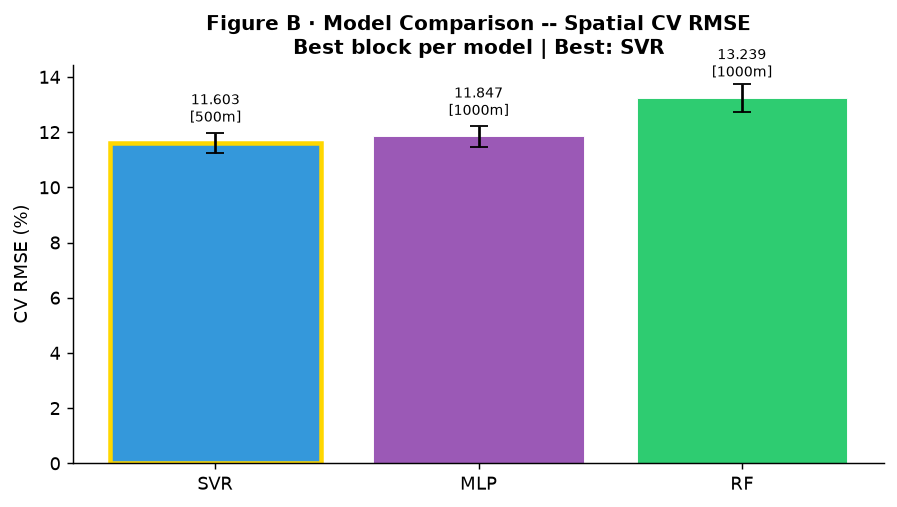

Figure B saved.


In [69]:
# Figure B -- Model CV RMSE comparison (best block per model)
cv_summary = []
for name in tuned_models:
    b  = best_block_per_model[name]
    df = all_results[(name, b)]
    cv_summary.append({'Model': name, 'Block': b,
                        'CV RMSE': round(df['RMSE'].mean(), 3),
                        'CV Std':  round(df['RMSE'].std(), 3)})
cv_df = pd.DataFrame(cv_summary).sort_values('CV RMSE').reset_index(drop=True)

print('===================================================')
print('  Model Comparison -- Spatial CV RMSE (best block)')
print('===================================================')
print(cv_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors_m = [MODEL_COLORS.get(m, '#95a5a6') for m in cv_df['Model']]
bars = ax.bar(cv_df['Model'], cv_df['CV RMSE'],
              yerr=cv_df['CV Std'], color=colors_m,
              edgecolor='white', capsize=5, linewidth=0.5)
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)
for bar, row in zip(bars, cv_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f'{row._3:.3f}\n[{row.Block}]', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('CV RMSE (%)')
ax.set_title(f'Figure B · Model Comparison -- Spatial CV RMSE\n' +
             f'Best block per model | Best: {cv_df.iloc[0]["Model"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figB_model_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure B saved.')


---
## Cell 19 · Figure C — Per-class accuracy


-- Per-Class Accuracy -- GEE_RF --
 Class       Label   N  RMSE   MAE   Bias      R2  Over-pred  Under-pred
     0     C0 (0%) 137 12.46  7.55  -7.55   0.000       99.3         0.0
     1  C1 (1-20%) 136 14.28 10.85 -10.10 -13.691       90.4         9.6
     2 C2 (21-40%) 134 14.78 10.78  -5.38  -5.519       63.4        36.6
     3 C3 (41-60%) 151 14.75 11.76  -0.39  -5.299       51.7        48.3
     4 C4 (61-80%) 153 14.03 11.59   4.24  -5.033       38.6        61.4
     5 C5 (81-99%) 166 15.87 12.76  11.86  -6.412       12.0        88.0
     6   C6 (100%) 137 11.84  8.78   8.78   0.000        0.0       100.0


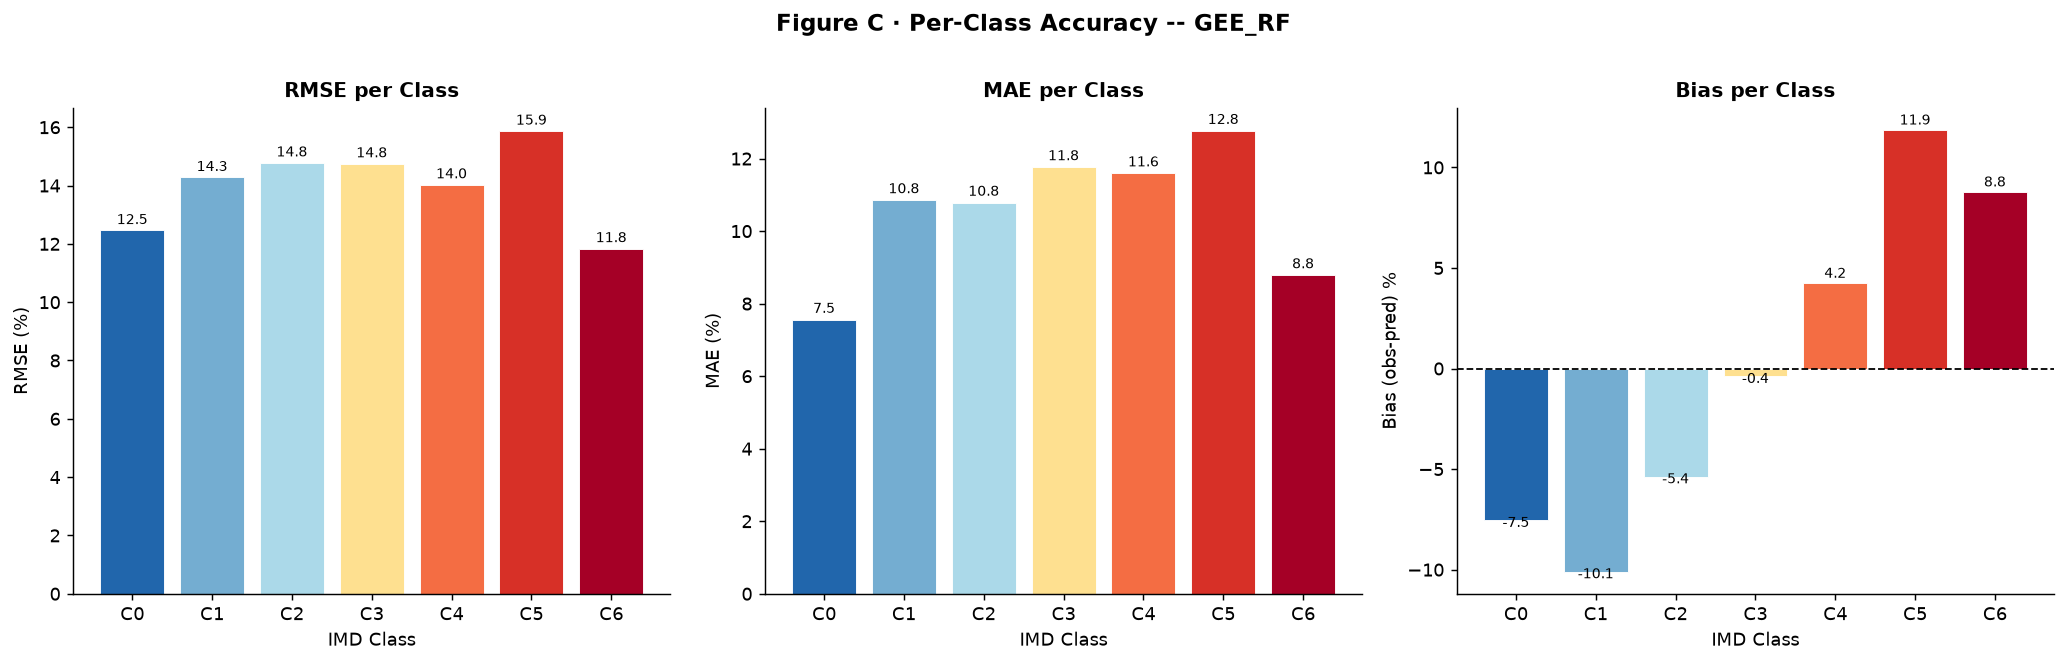

Figure C saved for GEE_RF.

-- Per-Class Accuracy -- GEE_SVR --
 Class       Label   N  RMSE   MAE   Bias      R2  Over-pred  Under-pred
     0     C0 (0%) 137 13.07  7.88  -7.88   0.000       73.7         0.0
     1  C1 (1-20%) 136 16.37 12.86 -10.72 -18.296       80.9        19.1
     2 C2 (21-40%) 134 16.14 13.00  -7.51  -6.772       69.4        30.6
     3 C3 (41-60%) 151 14.76 12.41  -1.92  -5.307       58.3        41.7
     4 C4 (61-80%) 153 12.20  9.63   3.67  -3.566       38.6        61.4
     5 C5 (81-99%) 166 16.56 13.65  13.10  -7.072        7.8        92.2
     6   C6 (100%) 137 13.47 10.04  10.04   0.000        0.0        83.9


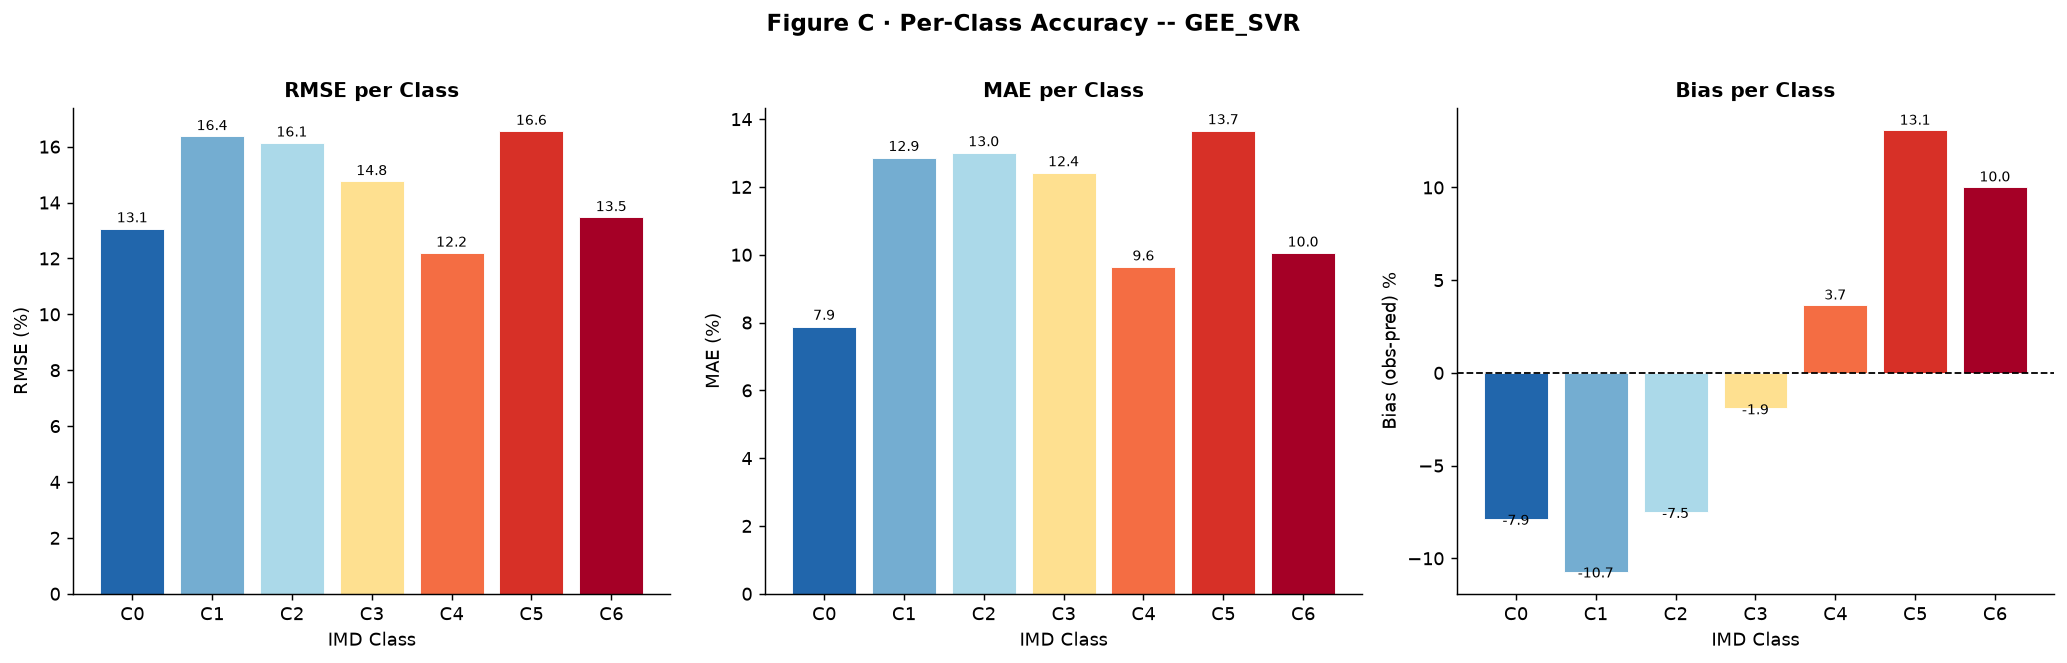

Figure C saved for GEE_SVR.


In [70]:
# Figure C -- Per-class accuracy
for name, res in holdout_results.items():
    yt    = res['y_true']
    yp    = res['y_pred']
    ct    = res['cls']

    class_metrics = []
    for c in range(N_CLASSES):
        m = ct == c
        if m.sum() < 2:
            continue
        obs_c = yt[m]; pred_c = yp[m]; res_c = obs_c - pred_c
        class_metrics.append({
            'Class':      c, 'Label': CLASS_LABELS[c], 'N': int(m.sum()),
            'RMSE':       round(float(np.sqrt(mean_squared_error(obs_c, pred_c))), 2),
            'MAE':        round(float(mean_absolute_error(obs_c, pred_c)), 2),
            'Bias':       round(float(np.mean(res_c)), 2),
            'R2':         round(float(r2_score(obs_c, pred_c)), 3) if m.sum() > 1 else np.nan,
            'Over-pred':  round(float((res_c < 0).mean() * 100), 1),
            'Under-pred': round(float((res_c > 0).mean() * 100), 1),
        })
    cls_df = pd.DataFrame(class_metrics)
    cls_df.to_csv(f'{OUTPUT_DIR}/perclass_metrics_{name}.csv', index=False)
    print(f'\n-- Per-Class Accuracy -- {name} --')
    print(cls_df.to_string(index=False))

    fig, axes_c = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric, ylabel in zip(axes_c, ['RMSE','MAE','Bias'],
                                   ['RMSE (%)','MAE (%)','Bias (obs-pred) %']):
        colors_c = [CLASS_COLORS[c] for c in cls_df['Class']]
        bars = ax.bar(cls_df['Class'], cls_df[metric], color=colors_c, edgecolor='white', lw=0.5)
        if metric == 'Bias':
            ax.axhline(0, color='black', lw=1, ls='--')
        for bar, val in zip(bars, cls_df[metric]):
            ypos = bar.get_height() + (0.1 if val >= 0 else -0.5)
            ax.text(bar.get_x()+bar.get_width()/2, ypos, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=8)
        ax.set_xticks(cls_df['Class'])
        ax.set_xticklabels([f'C{c}' for c in cls_df['Class']])
        ax.set_xlabel('IMD Class'); ax.set_ylabel(ylabel)
        ax.set_title(f'{metric} per Class', fontweight='bold')
    fig.suptitle(f'Figure C · Per-Class Accuracy -- {name}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/figC_perclass_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure C saved for {name}.')


---
## Cell 20 · Figure D — Feature importance (RF)

Computing permutation importance...


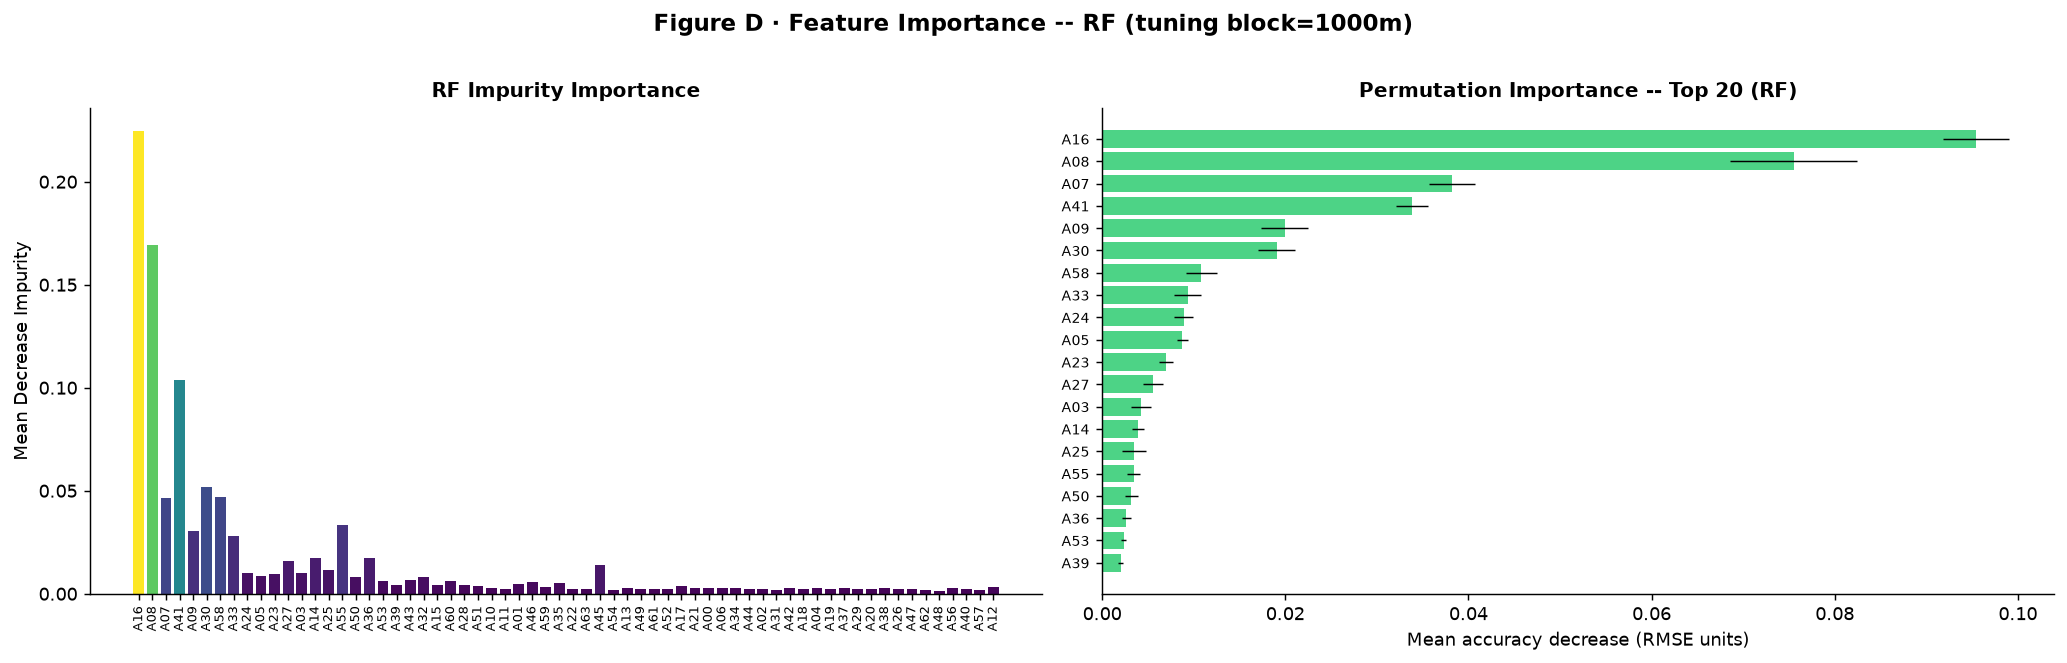

Figure D saved.


In [71]:
# Figure D -- Permutation importance (RF)
name = 'GEE_RF'
if name not in holdout_results:
    print(f'{name} not in holdout_results -- skipping.')
else:
    yt = holdout_results[name]['y_true']
    valid_mask   = ~np.isnan(np.clip(sample_raster_at_points(RF_RASTER_PATH, gdf_test), 0, 100))
    X_test_valid = X_test[valid_mask]

    rf_model = tuned_models['RF']
    print('Computing permutation importance...')
    perm     = permutation_importance(rf_model, X_test_valid, yt,
                                      n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    sort_idx = np.argsort(perm.importances_mean)[::-1]

    fig, axes_d = plt.subplots(1, 2, figsize=(16, 5))
    ax = axes_d[0]
    imp = rf_model.feature_importances_
    ax.bar(range(len(band_names)), imp[sort_idx],
           color=plt.cm.viridis(imp[sort_idx]/imp.max()), edgecolor='none')
    ax.set_xticks(range(len(band_names)))
    ax.set_xticklabels([band_names[i] for i in sort_idx], rotation=90, fontsize=7)
    ax.set_ylabel('Mean Decrease Impurity')
    ax.set_title('RF Impurity Importance', fontweight='bold')

    ax = axes_d[1]
    top20 = sort_idx[:20]
    ax.barh(range(20), perm.importances_mean[top20][::-1],
            xerr=perm.importances_std[top20][::-1],
            color=MODEL_COLORS['RF'], alpha=0.85, edgecolor='none',
            error_kw={'linewidth': 0.8, 'color': 'black'})
    ax.set_yticks(range(20))
    ax.set_yticklabels([band_names[i] for i in top20[::-1]], fontsize=8)
    ax.set_xlabel('Mean accuracy decrease (RMSE units)')
    ax.set_title('Permutation Importance -- Top 20 (RF)', fontweight='bold')

    fig.suptitle(f'Figure D · Feature Importance -- RF (tuning block={best_block_per_model["RF"]})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/figD_importance_RF.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure D saved.')


---
## Cell 21 · Figure E — Raster comparison map

In [72]:
# Figure E -- Raster comparison
DISPLAY_SCALE = 2
IMD_OBS_PATH  = 'data\IMD_2018_CLMS_fixed.tif'
IMD_PRED_PATH = RF_RASTER_PATH

imd_obs  = rxr.open_rasterio(IMD_OBS_PATH,  masked=False).squeeze('band', drop=True)[::DISPLAY_SCALE, ::DISPLAY_SCALE]
imd_pred = rxr.open_rasterio(IMD_PRED_PATH, masked=False).squeeze('band', drop=True)[::DISPLAY_SCALE, ::DISPLAY_SCALE]
if imd_pred.rio.crs != imd_obs.rio.crs or imd_pred.shape != imd_obs.shape:
    imd_pred = imd_pred.rio.reproject_match(imd_obs)
imd_diff = imd_pred - imd_obs
imd_cmap = ListedColormap(['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c'])

def imshow_aspect(ax, da, **kw):
    b  = da.rio.bounds()
    im = ax.imshow(da.values, extent=(b[0], b[2], b[1], b[3]), **kw)
    ax.set_aspect('equal')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xlabel('Easting [m]', fontsize=9); ax.set_ylabel('Northing [m]', fontsize=9)
    return im

fig, axes_e = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'wspace': 0.25, 'hspace': 0.04})
im1 = imshow_aspect(axes_e[0,0], imd_obs,  cmap=imd_cmap, vmin=0, vmax=100)
axes_e[0,0].set_title('Observed IMD (CLMS 2018)', fontweight='bold', fontsize=12)
im2 = imshow_aspect(axes_e[0,1], imd_pred, cmap=imd_cmap, vmin=0, vmax=100)
axes_e[0,1].set_title(f'Predicted IMD', fontweight='bold', fontsize=12)
im3 = imshow_aspect(axes_e[1,0], imd_diff, cmap='RdBu_r', vmin=-30, vmax=30)
axes_e[1,0].set_title('Difference (Predicted - Observed)', fontweight='bold', fontsize=12)
axes_e[1,1].axis('off')

fig.colorbar(im1, ax=axes_e[0,:], orientation='vertical', fraction=0.025, pad=0.02, label='IMD (%)')
fig.colorbar(im3, ax=axes_e[1,:], orientation='vertical', fraction=0.025, pad=0.02, label='Pred - Obs (%)')
# fig.suptitle(f'Figure E · IMD Observed vs Predicted vs Difference -- Milan\n' +
#             f'RF + AEF | tuning block={best_block_per_model["RF"]} | spatial test pts shown',
#             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/figE_raster_comparison_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure E saved.')

CPLE_NotSupportedError: Cannot find coordinate operations from '{   "$schema": "https://proj.org/schemas/v0.7/projjson.schema.json",   "type": "ProjectedCRS",   "name": "WGS 84 / UTM zone 32N",   "base_crs": {     "type": "GeographicCRS",     "name": "WGS 84",     "datum": {       "type": "GeodeticReferenceFrame",       "name": "World Geodetic System 1984",       "ellipsoid": {         "name": "WGS 84",         "semi_major_axis": 6378137,         "inverse_flattening": 298.257223563       }     },     "coordinate_system": {       "subtype": "ellipsoidal",       "axis": [         {           "name": "Longitude",           "abbreviation": "lon",           "direction": "east",           "unit": "degree"         },         {           "name": "Latitude",           "abbreviation": "lat",           "direction": "north",           "unit": "degree"         }       ]     }   },   "conversion": {     "name": "UTM zone 32N",     "method": {       "name": "Transverse Mercator",       "id": {       

In [ ]:
import rioxarray as rxr
da = rxr.open_rasterio("data/IMD_2018_CLMS.tif", masked=False)
da = da.rio.write_crs("EPSG:3035")                 # replace LOCAL_CS with proper EPSG:3035
da.rio.to_raster("data/IMD_2018_CLMS_fixed.tif")
print("saved, crs =", rxr.open_rasterio("data/IMD_2018_CLMS_fixed.tif").rio.crs)


CPLE_AppDefinedError: Deleting data/IMD_2018_CLMS_fixed.tif failed: Permission denied

---
## Cell 22 · Final summary

In [ ]:
print('='*75)
print('   FINAL SUMMARY -- SPATIALLY STRATIFIED DESIGN')
print('='*75)

print(f'\n0. SPATIAL TRAIN/TEST SPLIT ({SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer):')
print(f'   Train: {len(train_idx)} pts | Test: {len(test_idx)} pts')
print(f'   Test fraction: {100*len(test_idx)/(len(train_idx)+len(test_idx)):.1f}%')

print('\n1. HYPERPARAMETER TUNING (spatial block CV on training set):')
for name in tuned_models:
    b    = best_block_per_model[name]
    rmse = tune_df[(tune_df['Model']==name) & (tune_df['Block']==b)]['CV_RMSE'].values[0]
    print(f'  {name:<8}: best block={b}  CV RMSE={rmse:.3f}')

print(f'\n2. SPATIAL CV EVALUATION (buffer={BUFFER_M}m, {N_FOLDS}-fold, training set only):')
pivot = summary_df.pivot_table(index='Model', columns='CV_method', values='RMSE_mean')[CV_LABELS]
print(pivot.round(2).to_string())

print(f'\n3. SPATIAL HOLDOUT TEST SET:')
print(holdout_df.to_string(index=False))

print(f'\n* Best model: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}')

print('\n4. SPATIAL AUTOCORRELATION INFLATION:')
for name in tuned_models:
    b   = best_block_per_model[name]
    rnd = all_results[(name, 'Random')]['RMSE'].mean()
    sp  = all_results[(name, b)]['RMSE'].mean()
    print(f'  {name}: {sp-rnd:+.2f}% RMSE ({100*(sp-rnd)/rnd:+.1f}% relative) at {b} blocks')

print('\nOutputs:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<50} {sz/1024:>8.1f} kB')
print('='*75)

   FINAL SUMMARY -- SPATIALLY STRATIFIED DESIGN

0. SPATIAL TRAIN/TEST SPLIT (1000m blocks, 250m buffer):
   Train: 2449 pts | Test: 1014 pts
   Test fraction: 29.3%

1. HYPERPARAMETER TUNING (spatial block CV on training set):
  RF      : best block=1000m  CV RMSE=13.162
  SVR     : best block=500m  CV RMSE=11.711
  MLP     : best block=500m  CV RMSE=12.020

2. SPATIAL CV EVALUATION (buffer=250m, 5-fold, training set only):
CV_method  Random   500m  1000m  2000m
Model                                 
MLP         12.04  12.04  12.07  12.02
RF          13.24  13.26  13.24  13.20
SVR         11.61  11.60  11.60  11.60

3. SPATIAL HOLDOUT TEST SET:
  Model   RMSE    MAE    R2  Bias
 GEE_RF 14.123 10.675 0.837 0.624
GEE_SVR 14.756 11.400 0.822 0.274

* Best model: SVR @ 500m

4. SPATIAL AUTOCORRELATION INFLATION:
  RF: +0.00% RMSE (+0.0% relative) at 1000m blocks
  SVR: -0.01% RMSE (-0.1% relative) at 500m blocks
  MLP: -0.01% RMSE (-0.0% relative) at 500m blocks

Outputs:
  IMD_predicted_